In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import barnaba as bb
import os

In [2]:
BME_DIR = "bme_reweight"
tag = "hcp_rdc_3j_theta=16"
weights = np.load(f"{BME_DIR}/crossvals/crossval_{tag}/weights_results.npy")[0]
weights = weights.T
sub = "random_noReplace" #indicator which subensemble should be used
rdc_calc = np.loadtxt(f'calc_data/calc_rdc_loop_bme.dat')[:,1:]
w0 = np.full(rdc_calc.shape[0], 1/rdc_calc.shape[0]) # sample weights

# Plot Weight Figure
Shows distribution of weighting of frames

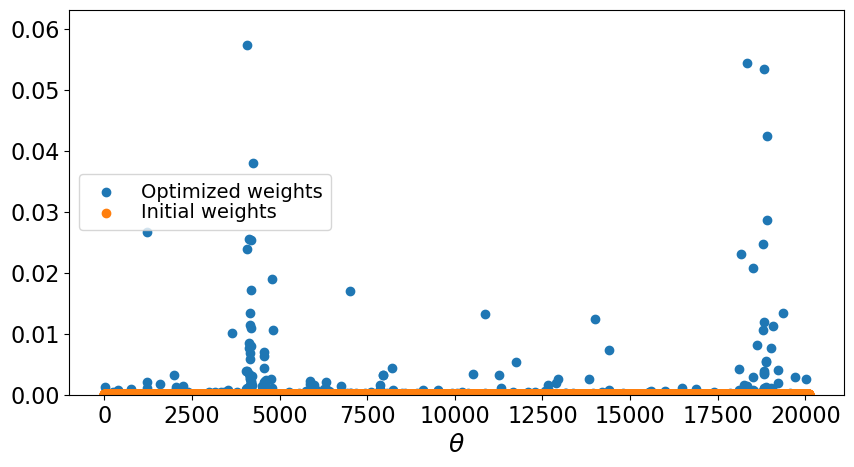

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
# load reweighted weights
w_new = weights


plt.scatter(range(len(w_new)),w_new,label="Optimized weights")
plt.scatter(range(len(w0)),w0,label="Initial weights")
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0,max(w_new)+max(w_new)/10)
plt.xlabel(r'$\theta$', fontsize=18)
plt.legend(fontsize=14, labelspacing=0.1)
plt.savefig(f"plots/weight_old_new_{tag}.pdf", facecolor='w')
plt.savefig(f"plots/weight_old_new_{tag}.png", facecolor='w')
plt.show()
plt.close()

## Add subsample frame marking

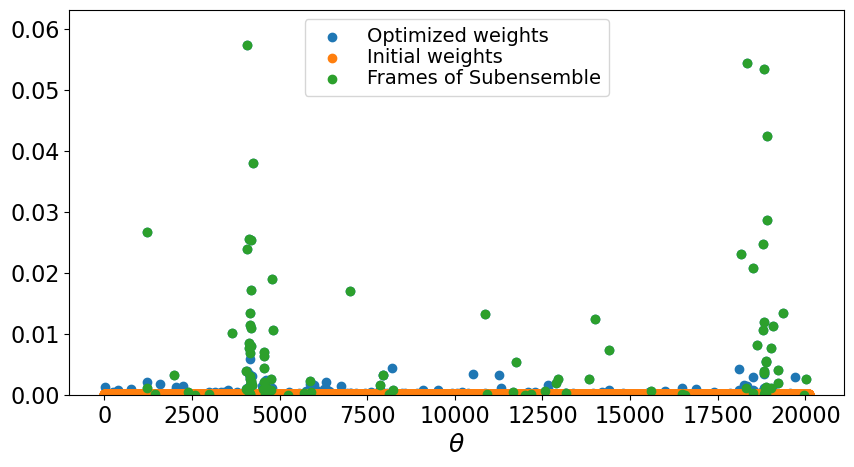

In [4]:
frames = np.load(f"qt_clustering_100/{tag}/subsampled_frames_{sub}.npy")

fig, ax = plt.subplots(figsize=(10, 5))

plt.scatter(range(len(w_new)),w_new,label="Optimized weights")
plt.scatter(range(len(w0)),w0,label="Initial weights")
plt.scatter(frames,w_new[frames],label="Frames of Subensemble")
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0,max(w_new)+max(w_new)/10)
plt.xlabel(r'$\theta$', fontsize=18)
plt.legend(fontsize=14, labelspacing=0.1)
plt.savefig(f"plots/weight_score_all_{tag}_random.pdf", facecolor='w')  # check name of savefile
plt.savefig(f"plots/weight_score_all_{tag}_random.png", facecolor='w')  # check name of savefile
plt.show()
plt.close()

## Plot Cluster Weight Distribution

In [5]:
# Load Clusters
cut = "cutoff_0_9"
cluster_array = np.loadtxt(f"qt_clustering_100/{tag}/QT_Clusters_{sub}_{cut}_minsize5.txt")
cluster_dict = {}
for cluster_id in set(cluster_array):
    cluster_dict[int(cluster_id)] = np.where(cluster_array==cluster_id)[0]
print(cluster_dict)

{0: array([ 0,  3, 10, 11, 14, 16, 22, 24, 26, 33, 35, 37, 40, 42, 44, 51, 53,
       56, 60, 62, 64, 73, 74, 77, 80, 85, 86, 88, 90, 91, 93, 95, 96],
      dtype=int64), 1: array([ 4,  5,  8, 19, 20, 34, 36, 41, 46, 49, 52, 57, 66, 76, 99],
      dtype=int64), 2: array([ 9, 13, 17, 28, 29, 43, 67, 81, 83, 87], dtype=int64), 3: array([50, 54, 70, 82, 92, 94], dtype=int64), 4: array([18, 32, 58, 59, 61], dtype=int64), -1: array([ 1,  2,  6,  7, 12, 15, 21, 23, 25, 27, 30, 31, 38, 39, 45, 47, 48,
       55, 63, 65, 68, 69, 71, 72, 75, 78, 79, 84, 89, 97, 98],
      dtype=int64)}


In [6]:
# load frames
frames = np.load(f"qt_clustering_100/{tag}/subsampled_frames_{sub}.npy")
frames_dict = {}
for cluster_id in set(cluster_array):
    id = cluster_dict[cluster_id]
    frames_dict[int(cluster_id)] = frames[id]
print(frames_dict)

{0: array([ 4238, 20006,  2973,  1447, 19968, 13181, 13826,  5238, 12882,
        5854,  1228, 12558,  3634, 13996, 16565, 12953, 11753,  5806,
        8247,  7877,  8111,  7942,  2373, 19375, 14388, 12014, 11668,
        2587, 19224, 19221,  5700, 12175, 16469]), 1: array([4083, 4170, 4145, 4081, 4171, 4134, 4164, 4136, 4132, 4148, 4166,
       4162, 4133, 4154, 4089]), 2: array([18893, 18891, 18890, 18829, 18887, 18883, 18830, 18884, 18852,
       18841]), 3: array([4608, 4543, 4562, 4561, 4556, 4576]), 4: array([4201, 4182, 4177, 4173, 4191]), -1: array([ 4781, 18809, 18320, 18803, 18498, 18629,  4049, 10850, 18501,
       18317, 18833,  7020, 18812, 18163, 19069,  2000,  5882, 19012,
       15597,  1225,  4076,  4768,  4047, 18787,  4515,  4749, 10912,
        4818,  4147,  4626, 19011])}


### Calculate Cluster Weight Distribution

In [7]:
sum_all = 0
cluster_weights = {}
for i in frames_dict.keys():
    cluster_weights[i] = []
    for w in weights[frames_dict[i]]:
        cluster_weights[i].append(w)
    sum_all += np.sum(cluster_weights[i])

print(sum_all)

clu_list = []
clu_p_list = []
for i in frames_dict: 
    clu_list.append(i)
    clu_w = cluster_weights[i]
    clu_p = (np.sum(clu_w)/sum_all)*100
    clu_p_list.append(clu_p)
    print("Cluster", i, "weighting in %:", clu_p)
shares = np.column_stack((clu_list, clu_p_list))
# pd.DataFrame(shares).to_csv(f'plots/cluster_shares_{clustering}_{cutoff}.txt', sep='\t', index=False, header=['Cluster', 'Percentage of weight'])

0.7861186498249829
Cluster 0 weighting in %: 17.768411688969802
Cluster 1 weighting in %: 24.008707869523686
Cluster 2 weighting in %: 11.744138505681315
Cluster 3 weighting in %: 2.5534658796648997
Cluster 4 weighting in %: 5.0832116843845325
Cluster -1 weighting in %: 38.84206437177577


In [8]:
# Load Clusters
cluster_array = np.loadtxt(f"qt_clustering_100/{tag}/QT_Clusters_{sub}_{cut}_minsize5.txt")
cluster_dict = {}
for cluster_id in set(cluster_array):
    cluster_dict[int(cluster_id)] = np.where(cluster_array==cluster_id)[0]
print(cluster_dict)

{0: array([ 0,  3, 10, 11, 14, 16, 22, 24, 26, 33, 35, 37, 40, 42, 44, 51, 53,
       56, 60, 62, 64, 73, 74, 77, 80, 85, 86, 88, 90, 91, 93, 95, 96],
      dtype=int64), 1: array([ 4,  5,  8, 19, 20, 34, 36, 41, 46, 49, 52, 57, 66, 76, 99],
      dtype=int64), 2: array([ 9, 13, 17, 28, 29, 43, 67, 81, 83, 87], dtype=int64), 3: array([50, 54, 70, 82, 92, 94], dtype=int64), 4: array([18, 32, 58, 59, 61], dtype=int64), -1: array([ 1,  2,  6,  7, 12, 15, 21, 23, 25, 27, 30, 31, 38, 39, 45, 47, 48,
       55, 63, 65, 68, 69, 71, 72, 75, 78, 79, 84, 89, 97, 98],
      dtype=int64)}


cluster 0 [ 0  3 10 11 14 16 22 24 26 33 35 37 40 42 44 51 53 56 60 62 64 73 74 77
 80 85 86 88 90 91 93 95 96], 17.768411688969802
cluster 1 [ 4  5  8 19 20 34 36 41 46 49 52 57 66 76 99], 24.008707869523686
cluster 2 [ 9 13 17 28 29 43 67 81 83 87], 11.744138505681315
cluster 3 [50 54 70 82 92 94], 2.5534658796648997
cluster 4 [18 32 58 59 61], 5.0832116843845325
cluster -1 [ 1  2  6  7 12 15 21 23 25 27 30 31 38 39 45 47 48 55 63 65 68 69 71 72
 75 78 79 84 89 97 98], 38.84206437177577


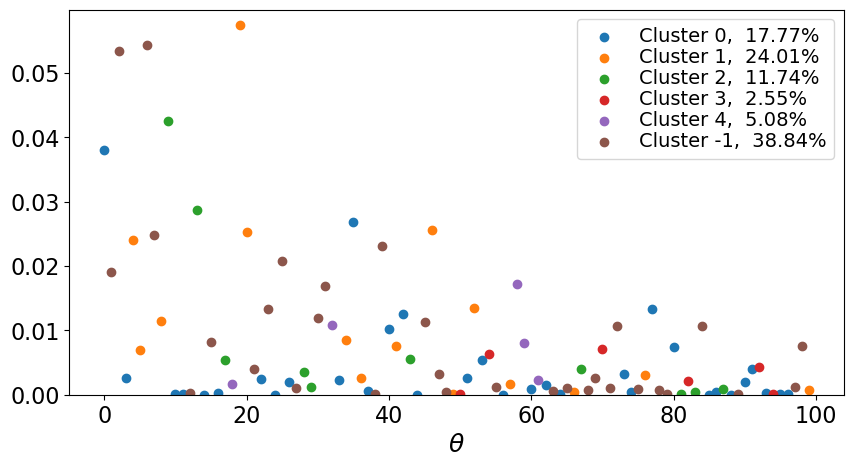

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
max_w = 0
for i in cluster_dict.keys():
    clu_w = cluster_weights[i]
    clu_f = cluster_dict[i] 
    clu_p = (np.sum(clu_w)/sum_all)*100
    print(f"cluster {i} {clu_f}, {clu_p}")
    if np.sum(clu_w) > max_w:
        max_w = np.max(clu_w)
    
    plt.scatter(clu_f,clu_w,label=f"Cluster {i},  {round(clu_p, 2)}%")
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0,max_w +(max_w/10))
plt.xlabel(r'$\theta$', fontsize=18)
plt.legend(fontsize=14, labelspacing=0.1)
plt.savefig(f"plots/weight_score_{tag}_{cut}.pdf", facecolor='w')
plt.savefig(f"plots/weight_score_{tag}_{cut}.png", facecolor='w')
plt.show()
plt.close()

### get weightings of unclustered but highly weighted frames

In [10]:
# get frame id:
# in this case last two frames of subensemble
unclu = []
for i in [-1, -2]: # define which frames are of interest
    unclu.append(frames[i])
    print(f"frame {i}:", frames[i])

print("Frame, weighting, share of subensemble")
for frame in unclu:
    w_unclu = w_new[frame]
    anteil = (w_unclu/sum_all)*100
    print(frame, w_unclu, anteil)

frame -1: 4089
frame -2: 19011
Frame, weighting, share of subensemble
4089 0.0006940836366395878 0.0882924780876417
19011 0.007632327904975584 0.9708875252704922


In [11]:
print("Frame in MD, Frame in Subensemble, weighting, share of subensemble, cluster")
high_frame = []
for i in frames:
    if w_new[i] > 0.02:
        pop = (w_new[i]/sum_all)*100
        clu_ind = cluster_array[frames.tolist().index(i)]
        if clu_ind == -1.0:
            print(i, (frames.tolist().index(i))+1, w_new[i], pop, clu_ind)
    

Frame in MD, Frame in Subensemble, weighting, share of subensemble, cluster
18809 3 0.053379722264802774 6.790288244234753 -1.0
18320 7 0.05437218824708818 6.916537123142073 -1.0
18803 8 0.024759043248882402 3.1495300683166105 -1.0
18501 26 0.020790817487123758 2.644742939472624 -1.0
18163 40 0.02305039729850953 2.9321778975274713 -1.0


# Calculate RMSE and $\chi^2$ comparing Experimental and (Reweighted) Calculated Data 

## Load Experimental, Calculated and Bundle Data

In [12]:

bundles = ["A", "2F87", "Farfar1", "Farfar2", "alphafold3"]

# labels
hcch_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_ccr_hcch_loop_bme.dat", delim_whitespace=True, usecols=[0]).index)
hcn_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_ccr_hcn_loop_bme.dat", delim_whitespace=True, usecols=[0]).index)
hcp_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_ccr_hcp_loop_bme.dat", delim_whitespace=True, usecols=[0]).index)
noe_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_noe_loop_bme.dat", delim_whitespace=True, usecols=[0])['#'])
j3_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_j3_bme.dat", delim_whitespace=True, usecols=[0]).index)
rdc_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_rdc_bme.dat", delim_whitespace=True, usecols=[0]).index)


# Experimental
rdc_exp = np.loadtxt(f"{BME_DIR}/exp_rdc_bme.dat",usecols=[1,2])
hcch_exp = np.loadtxt(f"{BME_DIR}/exp_ccr_hcch_loop_bme.dat",usecols=[1,2])
hcn_exp = np.loadtxt(f"{BME_DIR}/exp_ccr_hcn_loop_bme.dat",usecols=[1,2])
hcp_exp = np.loadtxt(f"{BME_DIR}/exp_ccr_hcp_loop_bme.dat",usecols=[1,2])
noe_exp = np.loadtxt(f"{BME_DIR}/exp_noe_loop_bme.dat",usecols=[1,2])
j3_exp = np.loadtxt(f"{BME_DIR}/exp_j3_bme.dat",usecols=[1,2])

## Experimental for PDB structure 2F87, which has different stem needs to be fitted with only loop rdcs
rdc_2F87_exp = np.loadtxt(f"{BME_DIR}/exp_rdc_loop_bme.dat",usecols=[1,2])
j3_2F87_exp = np.loadtxt(f"{BME_DIR}/exp_j3_2F87_bme.dat",usecols=[1,2])
hcch_2F87_exp = np.loadtxt(f"{BME_DIR}/exp_ccr_HCCH_2F87_loop_bme.dat",usecols=[1,2])
hcn_2F87_exp = np.loadtxt(f"{BME_DIR}/exp_ccr_HCN_2F87_loop_bme.dat",usecols=[1,2])
hcp_2F87_exp = np.loadtxt(f"{BME_DIR}/exp_ccr_HCP_2F87_loop_bme.dat",usecols=[1,2])
noe_2F87_exp = np.loadtxt(f"{BME_DIR}/exp_noe_2F87_loop_bme.dat",usecols=[1,2])

# Calculated
rdc_calc = np.loadtxt(f"{BME_DIR}/calc_rdc_bme.dat")[:,1:]
hcch_calc = np.loadtxt(f"{BME_DIR}/calc_ccr_hcch_loop_bme.dat")[:,1:]
hcn_calc = np.loadtxt(f"{BME_DIR}/calc_ccr_hcn_loop_bme.dat")[:,1:]
hcp_calc = np.loadtxt(f"{BME_DIR}/calc_ccr_hcp_loop_bme.dat")[:,1:]
noe_calc = np.loadtxt(f"{BME_DIR}/calc_noe_loop_bme.dat")[:,1:]
j3_calc = np.loadtxt(f"{BME_DIR}/calc_j3_bme.dat")[:,1:]

# Bundles
j3_bundles = {}
noe_bundles = {}
hcch_bundles = {}
hcn_bundles = {}
hcp_bundles = {}
rdc_bundles = {}
L_bundles = {}

for b in bundles:
    j3_bundles[b] = np.loadtxt(f'nmrbundle_data/nmrbundle_{b}_j3_loop_bme.dat')[:,1:]
    if b == "2F87":
        rdc_bundles[b] = np.loadtxt(f'nmrbundle_data/nmrbundle_{b}_rdc_loop_bme.dat')[:,1:]
    else:
        rdc_bundles[b] = np.loadtxt(f'nmrbundle_data/nmrbundle_{b}_rdc_all_bme.dat')[:,1:]
    hcch_bundles[b] = np.loadtxt(f'nmrbundle_data/nmrbundle_{b}_ccr_calc_HCCH_loop_bme.dat')[:,1:]
    hcn_bundles[b] = np.loadtxt(f'nmrbundle_data/nmrbundle_{b}_ccr_calc_HCN_loop_bme.dat')[:,1:]
    hcp_bundles[b] = np.loadtxt(f'nmrbundle_data/nmrbundle_{b}_ccr_calc_HCP_loop_bme.dat')[:,1:]
    noe_bundles[b] = np.loadtxt(f'nmrbundle_data/nmrbundle_{b}_dists_loop.dat')[:,1:]
    L_bundles[b] = np.load(f'nmrbundle_data/nmrbundle_{b}_rdc_all_bme_L.npy') 
    print(b)
    print("RDC:",rdc_bundles[b].shape)
    print("hcch:",hcch_bundles[b].shape)
    print("j3:",j3_bundles[b].shape)
    print("noe:",noe_bundles[b].shape)
# L_calc
L_calc = np.sum(rdc_exp[:,0]*np.average(rdc_calc, axis=0))/np.sum(np.average(rdc_calc, axis=0)*np.average(rdc_calc, axis=0))

# Reweighted weights
w_rew = weights

A
RDC: (20, 36)
hcch: (20, 12)
j3: (20, 36)
noe: (20, 135)
2F87
RDC: (13, 15)
hcch: (13, 10)
j3: (13, 29)
noe: (13, 108)
Farfar1
RDC: (20, 36)
hcch: (20, 12)
j3: (20, 36)
noe: (20, 135)
Farfar2
RDC: (10, 36)
hcch: (10, 12)
j3: (10, 36)
noe: (10, 135)
alphafold3
RDC: (5, 36)
hcch: (5, 12)
j3: (5, 36)
noe: (5, 135)


## Use RMSE Script to calc all RMSE

In [13]:
%load_ext autoreload
%autoreload 2
import os
import sys
module_path = os.path.abspath(os.path.join('lib')) # or the path to your source code
sys.path.insert(0, module_path)

In [14]:
import lib.rmse as rmse
from importlib import reload
reload(rmse)

<module 'lib.rmse' from 'z:\\14_MD_stuff\\20250709_GAAG_analysis_V4\\lib\\rmse.py'>

In [15]:
rmse_md = {}
# calc rmse for MD simulation compared to experimanetal data
rmse_md['MD'] = np.array([rmse.calc_RMSE_ensemble(rdc_exp, rdc_calc[:,:]*L_calc, w0), 
                          rmse.calc_RMSE_ensemble(j3_exp, j3_calc[:,:], w0), 
                          rmse.calc_RMSE_ensemble(hcch_exp, hcch_calc[:,:], w0),
                          rmse.calc_RMSE_ensemble(hcn_exp, hcn_calc[:,:], w0),
                          rmse.calc_RMSE_ensemble(hcp_exp, hcp_calc[:,:], w0), 
                          rmse.calc_RMSE_ensemble(noe_exp, noe_calc[:,:], w0, noe=True)])

# calc rmse for reweighted MD simulation compared to experimental data
rmse_md['MD+Exp'] = np.array([rmse.calc_RMSE_ensemble(rdc_exp, rdc_calc[:,:]*L_calc, w_rew[:].T), 
                              rmse.calc_RMSE_ensemble(j3_exp, j3_calc[:,:], w_rew[:]), 
                              rmse.calc_RMSE_ensemble(hcch_exp, hcch_calc[:,:], w_rew[:]), 
                              rmse.calc_RMSE_ensemble(hcn_exp, hcn_calc[:,:], w_rew[:]),
                              rmse.calc_RMSE_ensemble(hcp_exp, hcp_calc[:,:], w_rew[:]),
                              rmse.calc_RMSE_ensemble(noe_exp, noe_calc[:,:], w_rew[:], noe=True)])

w0_100 = np.array([1/100]*100)
rmse_md['Bundle MD+Exp'] = np.array([rmse.calc_RMSE_ensemble(rdc_exp, rdc_calc[frames,:]*L_calc, w0_100), 
                                     rmse.calc_RMSE_ensemble(j3_exp, j3_calc[frames,:], w0_100), 
                                     rmse.calc_RMSE_ensemble(hcch_exp, hcch_calc[frames,:], w0_100),
                                     rmse.calc_RMSE_ensemble(hcn_exp, hcn_calc[frames,:], w0_100),
                                     rmse.calc_RMSE_ensemble(hcp_exp, hcp_calc[frames,:], w0_100), 
                                     rmse.calc_RMSE_ensemble(noe_exp, noe_calc[frames,:], w0_100, noe=True)])

In [16]:
rmse_bundles = {}
for b in bundles:
    print(b)
    print( rdc_exp.shape,  (rdc_bundles[b][:,:].T*L_bundles[b]).T.shape)
    print(  j3_exp.shape,   j3_bundles[b][:,:].shape)
    print(hcch_exp.shape, hcch_bundles[b][:,:].shape)
    print( hcn_exp.shape,  hcn_bundles[b][:,:].shape)
    print( hcp_exp.shape,  hcp_bundles[b][:,:].shape)
    print( noe_exp.shape,  noe_bundles[b][:,:].shape)
    if b == "2F87":
        rmse_bundles[b] = np.array([
            rmse.calc_RMSE_bundle(rdc_2F87_exp, (rdc_bundles[b][:,:].T*L_bundles[b]).T), 
            rmse.calc_RMSE_bundle(j3_2F87_exp, j3_bundles[b][:,:]), 
            rmse.calc_RMSE_bundle(hcch_2F87_exp, hcch_bundles[b][:,:]),
            rmse.calc_RMSE_bundle( hcn_2F87_exp, hcn_bundles[b][:,:]),
            rmse.calc_RMSE_bundle( hcp_2F87_exp, hcp_bundles[b][:,:]), 
            rmse.calc_RMSE_bundle( noe_2F87_exp, noe_bundles[b][:,:])
        ])        
    else:
        rmse_bundles[b] = np.array([
            rmse.calc_RMSE_bundle(rdc_exp, (rdc_bundles[b][:,:].T*L_bundles[b]).T),
            rmse.calc_RMSE_bundle(j3_exp, j3_bundles[b][:,:]), 
            rmse.calc_RMSE_bundle(hcch_exp, hcch_bundles[b][:,:]),
            rmse.calc_RMSE_bundle(hcn_exp, hcn_bundles[b][:,:]),
            rmse.calc_RMSE_bundle(hcp_exp, hcp_bundles[b][:,:]), 
            rmse.calc_RMSE_bundle(noe_exp, noe_bundles[b][:,:])
        ])

A
(36, 2) (20, 36)
(36, 2) (20, 36)
(12, 2) (20, 12)
(5, 2) (20, 5)
(8, 2) (20, 8)
(135, 2) (20, 135)
2F87
(36, 2) (13, 15)
(36, 2) (13, 29)
(12, 2) (13, 10)
(5, 2) (13, 4)
(8, 2) (13, 5)
(135, 2) (13, 108)
Farfar1
(36, 2) (20, 36)
(36, 2) (20, 36)
(12, 2) (20, 12)
(5, 2) (20, 5)
(8, 2) (20, 8)
(135, 2) (20, 135)
Farfar2
(36, 2) (10, 36)
(36, 2) (10, 36)
(12, 2) (10, 12)
(5, 2) (10, 5)
(8, 2) (10, 8)
(135, 2) (10, 135)
alphafold3
(36, 2) (5, 36)
(36, 2) (5, 36)
(12, 2) (5, 12)
(5, 2) (5, 5)
(8, 2) (5, 8)
(135, 2) (5, 135)


In [17]:
rmse_err = np.array([
    np.sqrt(np.average(rdc_exp[:,1]**2, axis=-1)),
    np.sqrt(np.average(j3_exp[:,1]**2, axis=-1)),
    np.sqrt(np.average(hcch_exp[:,1]**2, axis=-1)),
    np.sqrt(np.average(hcn_exp[:,1]**2, axis=-1)),
    np.sqrt(np.average(hcp_exp[:,1]**2, axis=-1)),
    np.power(np.average(np.power(noe_exp[:,1], -6), axis=0), -1.0 / 6),
])

In [18]:
np.power(np.average(np.power(noe_exp[:,1], -6), axis=0), -1.0 / 6)

0.7059391400463275

# Plot RMSE


RDC [Hz]
MD: 5.65 +/- 1.5
MD+Exp: 3.12 +/- 1.5
Bundle
MD+Exp: 3.56 +/- 1.5
A: average: 5.58, max: 6.75
2F87: average: 7.73, max: 7.84
Farfar1: average: 5.66, max: 5.97
Farfar2: average: 6.02, max: 6.24
alphafold3: average: 4.76, max: 5.54

3J [Hz]
MD: 3.00 +/- 1.32
MD+Exp: 1.93 +/- 1.32
Bundle
MD+Exp: 2.01 +/- 1.32
A: average: 4.50, max: 5.11
2F87: average: 4.81, max: 6.77
Farfar1: average: 3.56, max: 4.05
Farfar2: average: 3.42, max: 3.64
alphafold3: average: 3.11, max: 3.18

$\Gamma$-HCCH [Hz]
MD: 11.32 +/- 2.04
MD+Exp: 5.98 +/- 2.04
Bundle
MD+Exp: 6.58 +/- 2.04
A: average: 10.17, max: 10.63
2F87: average: 12.93, max: 13.24
Farfar1: average: 12.65, max: 12.99
Farfar2: average: 11.87, max: 12.12
alphafold3: average: 10.45, max: 10.52

$\Gamma$-HCN [Hz]
MD: 3.70 +/- 1.14
MD+Exp: 3.10 +/- 1.14
Bundle
MD+Exp: 3.35 +/- 1.14
A: average: 2.22, max: 2.77
2F87: average: 6.23, max: 7.56
Farfar1: average: 4.58, max: 6.94
Farfar2: average: 4.66, max: 5.53
alphafold3: average: 4.38, max: 4.64

$

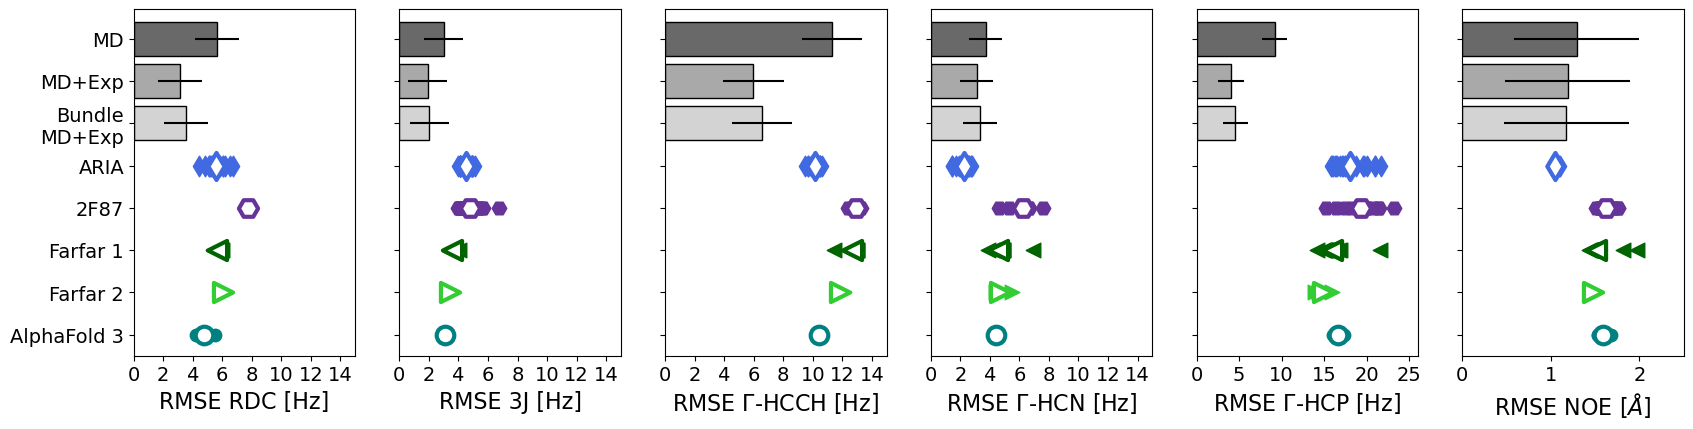

In [19]:
bundle_labels = ["ARIA", "2F87", "Farfar 1", "Farfar 2", "AlphaFold 3"]

greys = ['dimgrey', 'darkgrey', 'lightgrey']
lbl = ['RDC [Hz]', '3J [Hz]', r'$\Gamma$-HCCH [Hz]', r'$\Gamma$-HCN [Hz]',r'$\Gamma$-HCP [Hz]', r'NOE [$\AA$]']
x_lbl = ['MD', 'MD+Exp', 'Bundle\nMD+Exp'] + bundle_labels

lbl_dict_ = {
    # 3J:
    "C4Pb": r"$\rm ^3J(C4'_{i}\!,\!P_{i})$",
    "C4Pe": r"$\rm ^3J(C4'_{i}\!,\!P_{i\!+\!1})$",
    "1H5P": r"$\rm ^3J(H5'\!,\!P_{i})$",
    "2H5P": r"$\rm ^3J(H5''\!,\!P_{i})$",
    "1H5H4": r"$\rm ^3J(H4'\!,\!H5')$",
    "2H5H4": r"$\rm ^3J(H4'\!,\!H5'')$",
    "H1H2": r"$\rm ^3J(H1'\!,\!H2')$",
    "H2H3": r"$\rm ^3J(H2'\!,\!H3')$",
    "H3H4": r"$\rm ^3J(H3'\!,\!H4')$",
    "H3P": r"$\rm ^3J(H3'\!,\!P_{i\!+\!1})$",
    
    # CCR:
    "C1-C2": r"$\rm \Gamma^{DD\!,\!DD}_{(C1'H1'\!,\!C2'H2')}$",
    "C3-C4": r"$\rm \Gamma^{DD\!,\!DD}_{(C3'H3'\!,\!C4'H4')}$",
    "C4p-P": r"$\rm \Gamma^{DD\!,\!CSA}_{(C4'_iH4_i\!,\!P_{i})}$",
    "C3p-P-plus": r"$\rm \Gamma^{DD\!,\!CSA}_{(C3'_iH3_i\!,\!P_{i\!+\!1})}$",
    "C4p-P-plus": r"$\rm \Gamma^{DD\!,\!CSA}_{(C4'_iH4_i\!,\!P_{i\!+\!1})}$",
    "C5p-P": r"$\rm \Gamma^{DD\!,\!CSA}_{(C5'_iH5_i\!,\!P_{i})}$",
    "C1-CC": r"$\rm \Gamma^{DD\!,\!DD}_{(C6H6/C8H8\!,\!C1'H1')}$",
            }

cc = ['royalblue', 'rebeccapurple', 'darkgreen', 'limegreen', 'teal'] #'skyblue','#56B4E9', '#009E74', '#D55C00', '#F0E442', '#826aed', '#ff90b3', '#f7d9a7'
markers = ['d', 'H', '<', '>', 'o', 'v','D']
msizes = [110, 110, 110, 110, 80, 110, 80] # markersizes

fig, axes= plt.subplots(1,len(lbl),figsize=[20,4.5], sharey=True)


for i in range(len(lbl)):
    print(f'\n{lbl[i]:}')
    plt.subplot(1,len(lbl),i+1)
    for j,k in enumerate(rmse_md.keys()):
        if i == len(lbl):
            plt.barh(x_lbl[j], rmse_md[k][i], edgecolor='k', color=greys[j], height=0.8, xerr=np.array(rmse_md[k][i],rmse_err[i]))
        else:
            plt.barh(x_lbl[j], rmse_md[k][i], edgecolor='k', color=greys[j], height=0.8, xerr=rmse_err[i])
        print(f'{x_lbl[j]}: {rmse_md[k][i]:.2f} +/- {round(rmse_err[i],2)}')

    for j,k in enumerate(rmse_bundles.keys()):
        plt.scatter(rmse_bundles[k][i,:], [k for j in range(rmse_bundles[k].shape[-1])], marker=markers[j], color=cc[j], s=msizes[j])#, alpha=0.7)
        plt.scatter(np.average(rmse_bundles[k][i,:]), k, marker=markers[j], edgecolor=cc[j], color='w', s=msizes[j]+80, zorder=10, linewidths=3)
        print(f'{k}: average: {np.average(rmse_bundles[k][i,:]):.2f}, max: {np.max(rmse_bundles[k][i,:]):.2f}')
    
    plt.yticks(range(len(x_lbl)), x_lbl, rotation=0, fontsize=14)
    plt.xticks(fontsize=14)
    plt.xlabel(f'RMSE {lbl[i]}', fontsize=16)     
    plt.ylim(-0.7,len(x_lbl)-0.5) 
    plt.gca().invert_yaxis()
    for b in range(0,(len(lbl)-1)):
        if b == 4:
            x_range = 25
            plt.sca(axes[b])
            plt.xticks(range(0,x_range+1,5))
            plt.xlim(0,len(range(x_range+1))) 
        else:
            x_range = 14
            plt.sca(axes[b])
            plt.xticks(range(0,x_range+1,2))
            plt.xlim(0,len(range(x_range+1))) 
        
    plt.sca(axes[(len(lbl)-1)])
    #plt.xticks([0.00, 0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00])
    plt.xticks([0.00, 1.00, 2.00])
    plt.xlim(0,2.5)
#plt.tight_layout(pad=6)
# plt.savefig(f'plots/rmse_comp_all_horiz.png', dpi=300, facecolor='white', bbox_inches='tight')
plt.savefig(f'plots/rmse_comp_all_horiz.pdf', facecolor='white', bbox_inches='tight')
plt.savefig(f'plots/rmse_comp_all_horiz.png', facecolor='white', bbox_inches='tight')
plt.show()


# Calculate dihedral angles

In [20]:
angles_bb = ["alpha","beta","gamma","delta","eps","zeta","chi"]

bundles = ["A", "Farfar1", "Farfar2", "alphafold3"]
bundle_labels = ["ARIA", "Farfar 1", "Farfar 2", "AlphaFold 3"]

Load and get angles for PDB MD:

In [21]:
traj_f   = f'gaag_simulations/concat_traj_nopbc.xtc'
top_f    = f'gaag_simulations/initial_nopbc_mdtraj.pdb'
gaag_resid = ['C_5_0', 'G_6_0', 'A_7_0', 'A_8_0', 'G_9_0', 'G_10_0']

aa_md,res_md = bb.backbone_angles(traj_f, top_f, residues=gaag_resid, angles=angles_bb)
aa_md *= 180.0/np.pi
print(aa_md.shape)

# Loading gaag_simulations/concat_traj_nopbc.xtc 


(20100, 6, 7)


Load and get angles for bundles and 1RNG:

In [22]:
aa_bundles = {}
for b in bundles:
    aa_bundles[b] = rmse.get_angles_bundle(f'nmrbundle_data/Bundle_{b}.pdb', angles_bb,res_list=gaag_resid)*180.0/np.pi

# Loading nmrbundle_data/Bundle_A.pdb 


(20, 6, 7)


# Loading nmrbundle_data/Bundle_Farfar1.pdb 
# Loading nmrbundle_data/Bundle_Farfar2.pdb 


(20, 6, 7)
(10, 6, 7)
(5, 6, 7)


# Loading nmrbundle_data/Bundle_alphafold3.pdb 


In [ ]:
def get_measurement_idx(lbl_list, res, measurement):
    lbl = f'{res}:{measurement}'
    idx = lbl_list.index(lbl)
    return idx

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx #array[idx]

def plot_angle_measurement(res, angle, measurements, mtype, save=False): #residue='U7', angle='delta', measurements=['C1-C2', 'C3-C4'], measurement_type='ccr'/'j3'
    markers = ['d', 'H', '<', '>', 'o', 'v','D']
    msizes = [110, 110, 110, 110, 80, 110, 80] # markersizes
    
    if(angle=="delta"):
        ang_add = 360
    elif(angle=="alpha" or angle == "beta" or angle == "gamma" or angle == "zeta" or angle == "eps"):
        ang_add = 360
        bins=np.linspace(0,360,90)
    else:
        bins=np.linspace(-180,180,90)

    idxs = []
    for m in measurements:
        if mtype == 'hcch':
            idxs.append(get_measurement_idx(hcch_lbl, res, m))
            data_e, data_c, data_b = hcch_exp, hcch_calc, hcch_bundles
            ylbl = 'CCR [Hz]'
        if mtype == 'hcn':
            idxs.append(get_measurement_idx(hcn_lbl, res, m))
            data_e, data_c, data_b = hcn_exp, hcn_calc, hcn_bundles
            ylbl = 'CCR [Hz]'
        if mtype == 'hcp':
            idxs.append(get_measurement_idx(hcp_lbl, res, m))
            data_e, data_c, data_b = hcp_exp, hcp_calc, hcp_bundles
            ylbl = 'CCR [Hz]'
        elif mtype == 'j3':
            idxs.append(get_measurement_idx(j3_lbl, res, m))
            data_e, data_c, data_b = j3_exp, j3_calc, j3_bundles
            ylbl = r'$\mathregular{^3J}$ [Hz]'
        else:
            print('Check measurement type!')
            break


    fig, ax = plt.subplots(2,1, figsize=[10,9])
    ###### UPPER PANEL ######
    for i,idx in enumerate(idxs):
        # Exp:
        err = ax[0].errorbar(0.8+i, data_e[idx,0], yerr=data_e[idx,1], c='k', marker='s', ls='', markersize=9, elinewidth=2., capthick=2., capsize=12, zorder=10, label='Exp') # This is just for the legend
        ax[0].errorbar(0.8+i, data_e[idx,0], yerr=data_e[idx,1], c='k', marker='s', ls='', markersize=9, elinewidth=2.5, capthick=2.5, capsize=210/len(measurements), zorder=10, label='Exp')
        # MD:
        hh, ee = np.histogram(data_c[:,idx], bins=50, density=True)
        ax[0].plot((hh/hh.max()*0.1*len(measurements))+(.833+i), 0.5*(ee[1:] + ee[:-1]), c='dimgrey', lw=4, zorder=8)
        ax[0].scatter(np.array((hh/hh.max()*0.1*len(measurements))+(.833+i))[find_nearest(0.5*(ee[1:] + ee[:-1]), np.average(data_c[:,idx]))], np.average(data_c[:,idx]), marker='o', s=170, edgecolor=None, color='dimgrey', zorder=8.5)
        # MD:
        hh, ee = np.histogram(data_c[:,idx], bins=50, density=True, weights=w_rew)
        ax[0].plot((hh/hh.max()*0.1*len(measurements))+(.833+i), 0.5*(ee[1:] + ee[:-1]), c='darkgrey', lw=4, ls='--', dashes=(2,1), zorder=9)
        ax[0].scatter(np.array((hh/hh.max()*0.1*len(measurements))+(.833+i))[find_nearest(0.5*(ee[1:] + ee[:-1]), np.average(data_c[:,idx], weights=w_rew))], np.average(data_c[:,idx], weights=w_rew), marker='o', s=120, edgecolor=None, color='darkgrey',zorder=9.5)
        # MD+Exp bundle:
        ax[0].scatter([0.75+i]*len(frames), data_c[frames,idx], s=80, marker='o', color='lightgrey')#, alpha=0.7)
        ax[0].scatter([0.75+i], np.average(data_c[frames,idx], axis=0), s=230, marker='o', edgecolor='lightgrey', color='w', linewidths=4)
        # NMR Bundles + 1RNG:
        for b,bun in enumerate(bundles):
            ax[0].scatter([0.7+i-(0.07*b)]*len(data_b[bun]), data_b[bun][:,idx], s=msizes[b], marker=markers[b], color=cc[b])#, alpha=0.7)
            ax[0].scatter([0.7+i-(0.07*b)], np.average(data_b[bun][:,idx], axis=0), s=msizes[b]+110, marker=markers[b], edgecolor=cc[b], color='w', linewidths=3)

    # ax[0].set_xticks(np.arange(0.8, (0.8+i)*len(measurements)))
    ax[0].set_xticks([0.8+i for i in range(len(measurements)) ])
    ax[0].set_xticklabels([f'{res}:{lbl_dict_[m]}' for m in measurements])        
    ax[0].tick_params(axis='both', which='major', labelsize=18)
    ax[0].set_ylabel(ylbl, fontsize=20)

    ###### LOWER PANEL ######
    # MD:
    # tors[np.where(tors<0)] += 2*np.pi
    aa = aa_md[:,int(res[1:])-5,angles_bb.index(angle)]
    aa[np.where(aa<0)] += ang_add
    hh,ee = np.histogram(aa, bins=bins, density=True, weights=w0)
    ax[1].plot(0.5*(ee[1:]+ee[:-1]), hh, c='dimgrey', lw=4, label='MD')
    # MD+Exp:
    hh,ee = np.histogram(aa, bins=bins, density=True, weights=w_rew)
    ax[1].plot(0.5*(ee[1:]+ee[:-1]), hh, c='darkgrey', lw=4, ls='--', label='MD', dashes=(2,1))
    # MD+Exp bundle:
    ax[1].scatter(aa[frames], [-0.18/180*np.pi]*len(aa[frames]), s=80, marker='o', color='lightgrey')#, alpha=0.7)
    # non MD bundles:
    for b,bun in enumerate(bundles):
        aa = aa_bundles[bun][:,int(res[1:])-5,angles_bb.index(angle)]
        aa[np.where(aa<0)] += ang_add
        ax[1].scatter(aa, [(-b/4/180*np.pi)-0.4/180*np.pi]*len(aa), s=msizes[b], marker=markers[b], color=cc[b])#, alpha=0.7)


    ax[1].set_xticks(np.arange(0,bins.max()+1,bins.max()/4))
    ax[1].tick_params(axis='both', which='major', labelsize=18)
    ax[1].set_xlabel(r'$\mathregular{{s1}}$ [$\degree$] '.replace('s1', '\\'+angle), fontsize=20)
    ax[1].set_ylabel('Density', fontsize=20)
    # Custom legend:
    handles1 =  [plt.Line2D([0], [0], lw=4, color='dimgrey', label='MD'),
                 plt.Line2D([0], [0], lw=4, ls='--', dashes=(2,1), color='darkgrey', label='MD+Exp'),
                 plt.Line2D([0], [0], lw=4, ls='', color='lightgrey', marker='o', markersize=8, label='Bundle MD+Exp')]
    handles2 =  [plt.Line2D([0], [0], lw=4, ls='', color=cc[i], marker=markers[i], markersize=msizes[i]/10, label=ii) for i,ii in enumerate(bundle_labels) ]
    fig.legend(handles=[item for sublist in [[err], handles1, handles2] for item in sublist], fontsize=16, ncol=4, loc='center', bbox_to_anchor=(0.53, 0.52), fancybox=True) #, edgecolor='k'

    plt.tight_layout(h_pad=10.5)
    if save == True:
        plt.savefig(f'plots/{res}_{angle}_{"_".join(measurements)}.pdf')
        # plt.savefig(f'plots/{res}_{angle}_{"_".join(measurements)}.png', dpi=300)
    plt.show()

def plot_angle_measurement_si(res, angle, measurements, mtype, save=False): #residue='U7', angle='delta', measurements=['C1-C2', 'C3-C4'], measurement_type='ccr'/'j3'
    
    if(angle=="delta"):
        bins=np.linspace(0,180,45)
        # bins=np.linspace(0,360,90)
        ang_add = 0
    elif(angle=="alpha" or angle == "beta" or angle == "gamma" or angle == "zeta" or angle == "eps"):
        # tors[np.where(tors<0)] += 2*np.pi
        ang_add = 360
        bins=np.linspace(0,360,90)
    else:
        bins=np.linspace(-180,180,90)

    idxs, xticks = [],[]
    for m in measurements:
        if mtype == 'ccr':
            # idxs.append(get_measurement_idx(ccr_lbl, res, m))
            data_e, data_c, data_b, data_lbl = ccr_exp, ccr_calc, ccr_bundles, ccr_lbl
            ylbl = 'CCR [Hz]'
        elif mtype == 'j3':
            # idxs.append(get_measurement_idx(j3_lbl, res, m))
            data_e, data_c, data_b, data_lbl = j3_exp, j3_calc, j3_bundles, j3_lbl
            ylbl = r'$\mathregular{^3J}$ [Hz]'
        else:
            print('Check measurement type!')
            break
        if f'{res}:{m}' in data_lbl: 
            idxs.append(get_measurement_idx(data_lbl, res, m))
            # xticks.append(f'{res}:{m}')
            xticks.append(f'{res}:{lbl_dict_[m]}')
        else:
            continue

    fig, ax = plt.subplots(2,1, figsize=[10,9])
    ###### UPPER PANEL ######
    err_ = None
    for i,idx in enumerate(idxs):
        # Exp:
        err_ = ax[0].errorbar(1+i, data_e[idx,0], yerr=data_e[idx,1], c='k', marker='s', ls='', markersize=9, elinewidth=2, capthick=2, capsize=10, zorder=10, label='Exp') # just for the legend
        ax[0].errorbar(1+i, data_e[idx,0], yerr=data_e[idx,1], c='k', marker='s', markersize=9, elinewidth=2.5, capthick=2.5, capsize=80, zorder=10) #capsize=210/len(measurements)
        # MD:
        hh, ee = np.histogram(data_c[:,idx], bins=50, density=True)
        ax[0].plot((hh/hh.max()*0.3)+(1.03+i), 0.5*(ee[1:] + ee[:-1]), c='dimgrey', lw=4, zorder=8)
        ax[0].scatter(np.array((hh/hh.max()*0.3)+(1.03+i))[find_nearest(0.5*(ee[1:] + ee[:-1]), np.average(data_c[:,idx]))], np.average(data_c[:,idx]), marker='o', s=170, edgecolor=None, color='dimgrey', zorder=8.5)
        # MD:
        hh, ee = np.histogram(data_c[:,idx], bins=50, density=True, weights=w_rew)
        ax[0].plot((hh/hh.max()*0.3)+(1.03+i), 0.5*(ee[1:] + ee[:-1]), c='darkgrey', lw=4, ls='--', dashes=(2,1), zorder=9)
        ax[0].scatter(np.array((hh/hh.max()*0.3)+(1.03+i))[find_nearest(0.5*(ee[1:] + ee[:-1]), np.average(data_c[:,idx], weights=w_rew))], np.average(data_c[:,idx], weights=w_rew), marker='o', s=120, edgecolor=None, color='darkgrey',zorder=9.5)
        # MD+Exp bundle:
        ax[0].scatter([0.93+i]*len(frames), data_c[frames,idx], s=80, marker='o', color='lightgrey')#, alpha=0.7)
        ax[0].scatter([0.93+i], np.average(data_c[frames,idx], axis=0), s=230, marker='o', edgecolor='lightgrey', color='w', linewidths=4)
        # NMR Bundles + 1RNG:
        for b,bun in enumerate(bundles):
            ax[0].scatter([0.85+i-(0.08*b)]*len(data_b[bun]), data_b[bun][:,idx], s=msizes[b], marker=markers[b], color=cc[b])#, alpha=0.7)
            ax[0].scatter([0.85+i-(0.08*b)], np.average(data_b[bun][:,idx], axis=0), s=msizes[b]+110, marker=markers[b], edgecolor=cc[b], color='w', linewidths=3)

    ax[0].set_xlim(0.3,3.4)
    ax[0].set_xticks(np.arange(1, len(xticks)+1))
    ax[0].set_xticklabels(xticks)        
    ax[0].tick_params(axis='both', which='major', labelsize=18)
    ax[0].set_ylabel(ylbl, fontsize=20)
    ###### LOWER PANEL ######
    # MD:
    aa = aa_md[:,int(res[1:])-5,angles_bb.index(angle)]
    aa[np.where(aa<0)] += ang_add
    hh,ee = np.histogram(aa, bins=bins, density=True, weights=w0)
    ax[1].plot(0.5*(ee[1:]+ee[:-1]), hh, c='dimgrey', lw=4, label='MD')
    # MD+Exp:
    hh,ee = np.histogram(aa, bins=bins, density=True, weights=w_rew)
    ax[1].plot(0.5*(ee[1:]+ee[:-1]), hh, c='darkgrey', lw=4, ls='--', label='MD', dashes=(2,1))
    # MD+Exp bundle:
    ax[1].scatter(aa[frames], [-0.18/180*np.pi]*len(aa[frames]), s=80, marker='o', color='lightgrey')#, alpha=0.7)
    # NMR bundles and 1RNG:
    for b,bun in enumerate(bundles):
        aa = aa_bundles[bun][:,int(res[1:])-5,angles_bb.index(angle)]
        aa[np.where(aa<0)] += ang_add

        ax[1].scatter(aa, [(-b/5/180*np.pi)-0.4/180*np.pi]*len(aa), s=msizes[b], marker=markers[b], color=cc[b])#, alpha=0.7)

    ax[1].set_xticks(np.arange(0,bins.max()+1,bins.max()/4))
    # ax[1].set_xticklabels(xticks)
    ax[1].tick_params(axis='both', which='major', labelsize=18)
    if angle=='eps':
        angle = 'epsilon'
    ax[1].set_xlabel(r'$\mathregular{{s1}}$ [$\degree$] '.replace('s1', '\\'+angle), fontsize=20)
    ax[1].set_ylabel('Density', fontsize=20)
    # Custom legend:
    
    
    handles1 =  [#err,#Line2D([0], [0], lw=4, ls='', color='k', marker='s', label='Exp'),
                 plt.Line2D([0], [0], lw=4, color='dimgrey', label='MD'),
                 plt.Line2D([0], [0], lw=4, ls='--', dashes=(2,1), color='darkgrey', label='MD+Exp'),
                 plt.Line2D([0], [0], lw=4, ls='', color='lightgrey', marker='o', markersize=8, label='Bundle MD+Exp')]
    handles2 =  [plt.Line2D([0], [0], lw=4, ls='', color=cc[i], marker=markers[i], markersize=msizes[i]/10, label=ii) for i,ii in enumerate(['Bundle 2_2', 'Bundle 1_3', '1ZIH', 'farfar_1', 'farfar_2']) ]
    if err_:
        fig.legend(handles=[item for sublist in [[err_], handles1, handles2] for item in sublist], fontsize=16, ncol=4, loc='center', bbox_to_anchor=(0.53, 0.52), fancybox=True) #, edgecolor='k'
    else:
        fig.legend(handles=[item for sublist in [handles1, handles2] for item in sublist], fontsize=16, ncol=3, loc='center', bbox_to_anchor=(0.53, 0.52), fancybox=True) #, edgecolor='k'

    plt.tight_layout(h_pad=9.5)
    if save == True:
        plt.savefig(f'plots/{res}_{angle}_{mtype}.pdf')
        plt.savefig(f'plots/{res}_{angle}_{"_".join(measurements)}.png', dpi=300)
    plt.show()
    return err_

# Basepairs and stackings

In [24]:
def get_pairing(pairings, pair_idx): # pair_idx = [0,13]
    """Return Base pairs and basepair labels"""

    bp = []
    bp_labels = []
    for p in pairings:
        if pair_idx in p[0]: # Check for bp
    #         bp_c5_g10.append(p[1][p[0].index([4,9])]) # Use if collecting the bps only
            if p[1][p[0].index(pair_idx)][:2] == 'WC' or p[1][p[0].index(pair_idx)][:2] == 'WW':
                bp.append(0)
                bp_labels.append('WW/WC')
            elif p[1][p[0].index(pair_idx)][:2] == 'XX':
                bp.append(2)
                bp_labels.append('None') #bp_labels.append('XX')
            else:
                bp.append(1)
                bp_labels.append('non-WW/WC')
        else:
            bp.append(0)
            bp_labels.append('None')
    return np.array(bp), bp_labels

def get_stacking(stackings, pair_idx, stack_type):
    st = []
    st_labels = []
    for s in stackings:
        if pair_idx in s[0]:
            if s[1][s[0].index(pair_idx)] == stack_type:
                st.append(1)
                st_labels.append(stack_type)
            else:
                st.append(0)
                st_labels.append('None')
        else:
            st.append(0)
            st_labels.append('None')
            
    return st#, st_label

## Get Basepairs and Stackings

### From MD Simulation

In [25]:
traj_f   = f'gaag_simulations/concat_traj_nopbc.xtc'
top_f    = f'gaag_simulations/initial_nopbc_mdtraj.pdb'

stackings,pairings,residues = bb.annotate(traj_f,topology=top_f)

# Loading gaag_simulations/concat_traj_nopbc.xtc 


### From Bundles

In [26]:
stacks_bundles, pairs_bundles, res_bundles = {}, {}, {}
for b in bundles:
    stacks_bundles[b], pairs_bundles[b], res_bundles[b] = bb.annotate(f'nmrbundle_data/Bundle_{b}.pdb')

# Loading nmrbundle_data/Bundle_A.pdb 
# Loading nmrbundle_data/Bundle_Farfar1.pdb 
# Loading nmrbundle_data/Bundle_Farfar2.pdb 
# Loading nmrbundle_data/Bundle_alphafold3.pdb 


['MD', 'MD+Exp', 'Bundle MD+Exp', 'ARIA', 'Farfar 1', 'Farfar 2', 'AlphaFold 3']


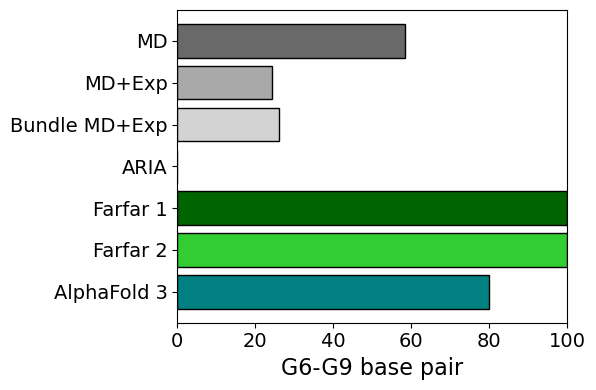

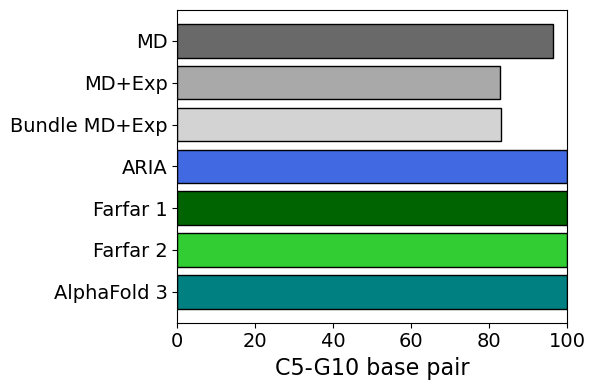

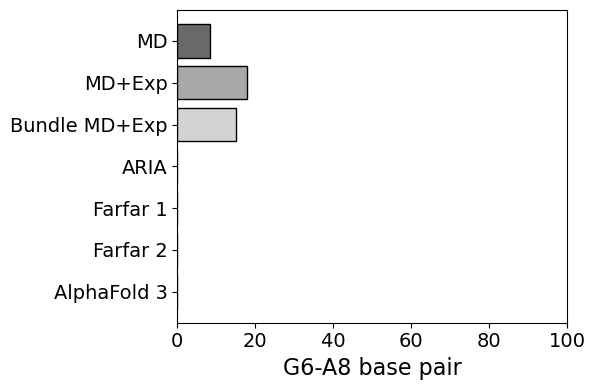

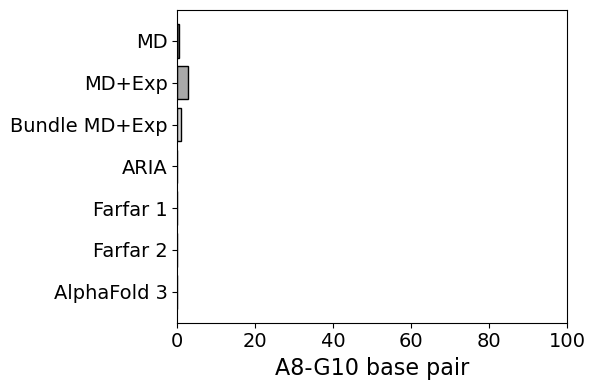

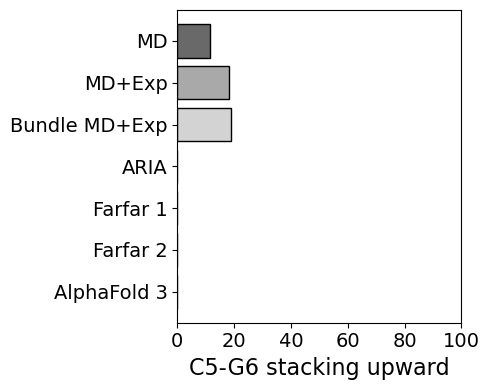

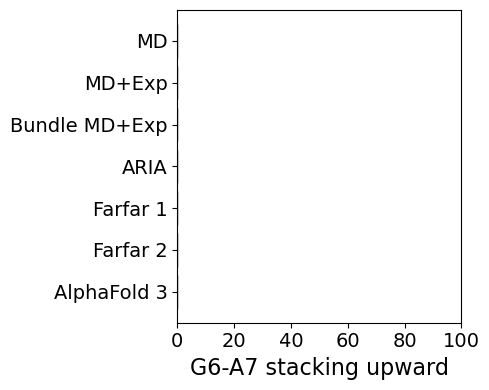

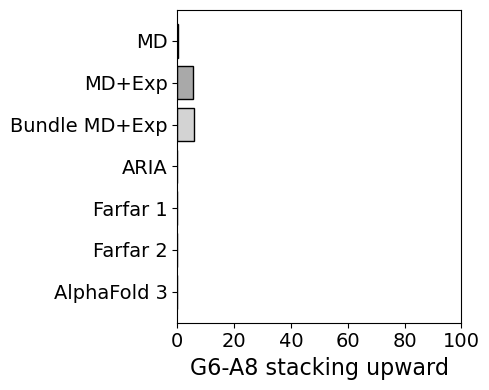

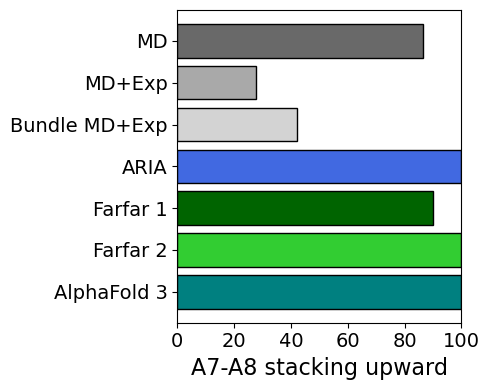

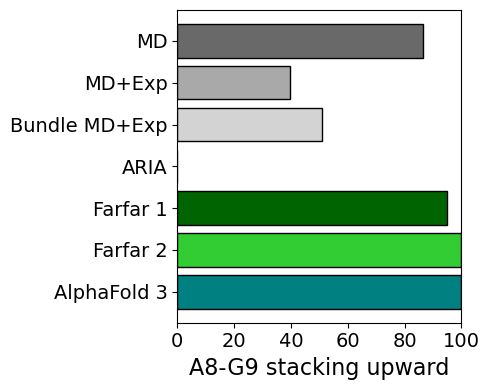

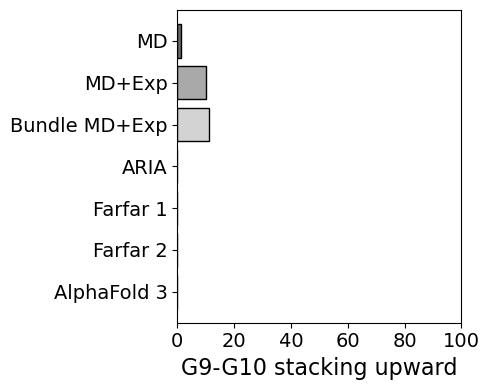

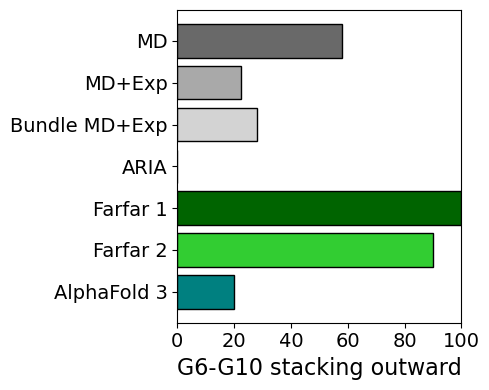

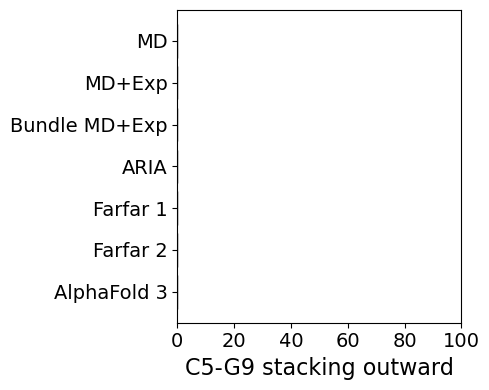

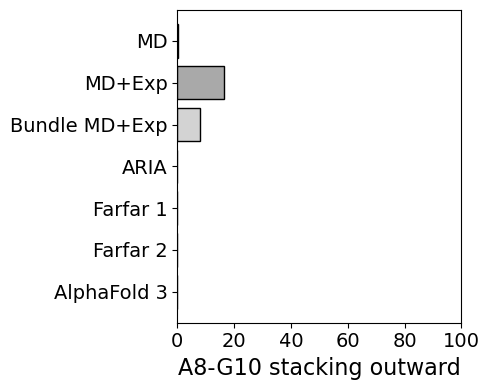

In [27]:
data_label = ['MD', 'MD+Exp','Bundle MD+Exp'] + bundle_labels
print(data_label)
#plt_coloring = ["dimgray","darkgray","lightgray","lightblue","lightcyan","aliceblue"]
plt_coloring = ["dimgray","darkgray","lightgray",'royalblue', 'darkgreen', 'limegreen', 'teal'] # MD, MD+Exp, Bundle_MD+Exp, 1+3, 2+2, 1ZIH, far, far_top10, alpha3
# Here you can define all secondary structures you are looking for                                                  ##56B4E9', '#009E74', '#D55C00', '#F0E442', '#826aed', '#ff90b3'
requested_annotations = [
                            {"residues": ("G_6","G_9"), "type": "bp"},
                            {"residues": ("C_5","G_10"), "type": "bp"},
                            {"residues": ("G_6","A_8"), "type": "bp"},
                            {"residues": ("A_8","G_10"), "type": "bp"},
                            
                            {"residues": ("C_5","G_6"), "type": "stack_up"},
                            {"residues": ("G_6","A_7"), "type": "stack_up"},
                            {"residues": ("G_6","A_8"), "type": "stack_up"},
                            {"residues": ("A_7","A_8"), "type": "stack_up"},
                            {"residues": ("A_8","G_9"), "type": "stack_up"},
                            {"residues": ("G_9","G_10"), "type": "stack_up"},

                            {"residues": ("G_6","G_10"), "type": "stack_out"},
                            {"residues": ("C_5","G_9"), "type": "stack_out"},
                            {"residues": ("A_8","G_10"), "type": "stack_out"},

                        ]
plt_files = []
plt_labels = []

for i in range(len(requested_annotations)):
    data = []
    annot = requested_annotations[i] 
    barnaba_index = (annot["residues"][0]+"_0", annot["residues"][1]+"_0") # Barnaba uses specific index for annotation for ex. G_6_0 for G6
    plot_name = "".join(annot["residues"]) + "_" + annot["type"]

    # Check if annotation is basepair
    if annot["type"] == "bp":
        _,bp_labels = get_pairing(pairings, pair_idx=[residues.index(barnaba_index[0]), residues.index(barnaba_index[1])])
        data.append(100*sum([sum([1 if i == k else 0 for i in bp_labels]*w0) for k in ['WW/WC', 'non-WW/WC']]))
        data.append(100*sum([sum([1 if i == k else 0 for i in bp_labels]*w_rew) for k in ['WW/WC', 'non-WW/WC']]))
        data.append(100*sum([sum([1 if i == k else 0 for i in np.array(bp_labels)[frames]]*np.full(len(frames), 1/len(frames))) for k in ['WW/WC', 'non-WW/WC']]))

        for ff,b in enumerate(bundles):
            _,bp_labels = get_pairing(pairs_bundles[b], pair_idx=[ res_bundles[b].index(barnaba_index[0]), res_bundles[b].index(barnaba_index[1])])
            p_bundle = 100*sum([np.average([1 if i == k else 0 for i in bp_labels]) for k in ['WW/WC', 'non-WW/WC']])
            data.append(p_bundle)


    # Check if annotation is inward stacking
    elif "stack" in annot["type"]:
        # Check if outward or inward stacking
        if annot["type"] == "stack_out":
            stack_type = "<>"
        elif annot["type"] == "stack_down":
            stack_type = "<<"
        elif annot["type"] == "stack_up":
            stack_type = ">>"
        elif annot["type"] == "stack_in":
            stack_type = "><"
        data.append(100*sum(get_stacking(stackings, [residues.index(barnaba_index[0]), residues.index(barnaba_index[1])], stack_type)*w0))
        data.append(100*sum(get_stacking(stackings, [residues.index(barnaba_index[0]), residues.index(barnaba_index[1])], stack_type)*w_rew))
        data.append(100*sum(np.array(get_stacking(stackings, [residues.index(barnaba_index[0]), residues.index(barnaba_index[1])], stack_type))[frames])/len(frames))

        for ff,b in enumerate(bundles):
            # _,g6_a9_md = get_pairing(pairs_bundles[f], pair_idx=[ res_bundles[f].index('G_6_0'), res_bundles[f].index('A_9_0')])
            p_bundle = 100*sum(get_stacking(stacks_bundles[b], [res_bundles[b].index(barnaba_index[0]), res_bundles[b].index(barnaba_index[1])], stack_type))/len(stacks_bundles[b])
            data.append(p_bundle)

    # Plot
    if annot["type"] == "bp":
        fig, ax = plt.subplots(figsize=[(20/3.3),4])
    else:
        fig, ax = plt.subplots(figsize=[5,4])
    

    
    bars = ax.barh(data_label[::-1], data[::-1],color=plt_coloring[::-1],edgecolor = "k")
    
    #ax.bar_label(bars, fmt=" {:,.2f}%")
    ax.set_xlim(0,100)
    if  annot["type"] == "bp":
        typ = "base pair"
    elif annot["type"] == "stack_out":
        typ = "stacking outward"
    elif annot["type"] == "stack_in":
        typ = "stacking inward"
    elif annot["type"] == "stack_up":
        typ = "stacking upward"
    elif annot["type"] == "stack_down":
        typ = "stacking downward"
    res0 = f'{annot["residues"][0].split("_")[0]}{annot["residues"][0].split("_")[1]}'
    res1 = f'{annot["residues"][1].split("_")[0]}{annot["residues"][1].split("_")[1]}'
    plt.xlabel(f'{res0}-{res1} {typ}', fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    

    plt.tight_layout(w_pad=5)
    out_dir = f"plots/{tag}/basepair_stacking_analysis"
    if not os.path.exists(out_dir):
        os.makedirs(out_dir)
    plt.savefig(f'{out_dir}/{plot_name}.pdf')
    plt.savefig(f'{out_dir}/{plot_name}.png')
    plt.show()
    plt_files.append(f'{out_dir}/{plot_name}.png')
    plt_labels.append(plot_name)

# SI Fig: CCR/3J + angle

In [28]:
j3_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_j3_bme.dat", delim_whitespace=True, usecols=[0]).index)
j3_lbl = [ f"{i.split('-')[0]}:{i.split('-')[1]}" for i in j3_lbl ]

In [ ]:
def get_measurement_idx(lbl_list, res, measurement):
    lbl = f'{res}:{measurement}'
    idx = lbl_list.index(lbl)
    return idx

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx #array[idx]

#bundle_labels = bundles

cc = ['royalblue', 'darkgreen', 'limegreen', 'teal'] #'skyblue', 'rebeccapurple',
def plot_angle_measurement_si(res, angle, measurements, mtype, save=False):
    
    if(angle=="delta"):
        #bins=np.linspace(0,180,45)
        bins=np.linspace(0,360,90)
        ang_add = 360
    elif(angle=="alpha" or angle == "beta" or angle == "gamma" or angle == "zeta" or angle == "eps" or angle=="chi"):
        # tors[np.where(tors<0)] += 2*np.pi
        ang_add = 360
        bins=np.linspace(0,360,90)
    else:
        bins=np.linspace(-180,180,90)

    idxs, xticks = [],[]
    for m in measurements:
        if mtype == 'hcch':
            # idxs.append(get_measurement_idx(ccr_lbl, res, m))
            data_e, data_c, data_b, data_lbl = hcch_exp, hcch_calc, hcch_bundles, hcch_lbl
            ylbl = 'CCR [Hz]'
        elif mtype == 'hcn':
            # idxs.append(get_measurement_idx(ccr_lbl, res, m))
            data_e, data_c, data_b, data_lbl = hcn_exp, hcn_calc, hcn_bundles, hcn_lbl
            ylbl = 'CCR [Hz]'
        elif mtype == 'hcp':
            # idxs.append(get_measurement_idx(ccr_lbl, res, m))
            data_e, data_c, data_b, data_lbl = hcp_exp, hcp_calc, hcp_bundles, hcp_lbl
            ylbl = 'CCR [Hz]'
        elif mtype == 'j3':
            # idxs.append(get_measurement_idx(j3_lbl, res, m))
            data_e, data_c, data_b, data_lbl = j3_exp, j3_calc, j3_bundles, j3_lbl
            ylbl = r'$\mathregular{^3J}$ [Hz]'
        else:
            print('Check measurement type!')
            break
        if f'{res}:{m}' in data_lbl: 
            idxs.append(get_measurement_idx(data_lbl, res, m))
            #xticks.append(f'{res}:{m}')
            xticks.append(f'{res}:{lbl_dict_[m]}')
        else:
            continue

    fig, ax = plt.subplots(2,1, figsize=[10,9])
    ###### UPPER PANEL ######
    err_ = None
    for i,idx in enumerate(idxs):
        # Exp:
        err_ = ax[0].errorbar(1+i, data_e[idx,0], yerr=data_e[idx,1], c='k', marker='s', ls='', markersize=9, elinewidth=2, capthick=2, capsize=10, zorder=10, label='Exp') # just for the legend
        ax[0].errorbar(1+i, data_e[idx,0], yerr=data_e[idx,1], c='k', marker='s', markersize=9, elinewidth=2, capthick=2.5, capsize=25*len(bundle_labels), zorder=10) #capsize=10
        # MD:
        hh, ee = np.histogram(data_c[:,idx], bins=50, density=True)
        ax[0].plot((hh/hh.max()*0.3)+(1.03+i), 0.5*(ee[1:] + ee[:-1]), c='dimgrey', lw=4, zorder=8)
        ax[0].scatter(np.array((hh/hh.max()*0.3)+(1.03+i))[find_nearest(0.5*(ee[1:] + ee[:-1]), np.average(data_c[:,idx]))], np.average(data_c[:,idx]), marker='o', s=170, edgecolor=None, color='dimgrey', zorder=8.5)
        # MD:
        hh, ee = np.histogram(data_c[:,idx], bins=50, density=True, weights=w_rew)
        ax[0].plot((hh/hh.max()*0.3)+(1.03+i), 0.5*(ee[1:] + ee[:-1]), c='darkgrey', lw=4, ls='--', dashes=(2,1), zorder=9)
        ax[0].scatter(np.array((hh/hh.max()*0.3)+(1.03+i))[find_nearest(0.5*(ee[1:] + ee[:-1]), np.average(data_c[:,idx], weights=w_rew))], np.average(data_c[:,idx], weights=w_rew), marker='o', s=120, edgecolor=None, color='darkgrey',zorder=9.5)
        # MD+Exp bundle:
        ax[0].scatter([0.93+i]*len(frames), data_c[frames,idx], s=80, marker='o', color='lightgrey')#, alpha=0.7)
        ax[0].scatter([0.93+i], np.average(data_c[frames,idx], axis=0), s=230, marker='o', edgecolor='lightgrey', color='w', linewidths=4)
        # NMR Bundles + 1RNG:
        for b,bun in enumerate(bundles):
            ax[0].scatter([0.85+i-(0.08*b)]*len(data_b[bun]), data_b[bun][:,idx], s=msizes[b], marker=markers[b], color=cc[b])#, alpha=0.7)
            ax[0].scatter([0.85+i-(0.08*b)], np.average(data_b[bun][:,idx], axis=0), s=msizes[b]+110, marker=markers[b], edgecolor=cc[b], color='w', linewidths=3)

    ax[0].set_xlim(0.3,3.4)
    ax[0].set_xticks(np.arange(1, len(xticks)+1))
    ax[0].set_xticklabels(xticks)        
    ax[0].tick_params(axis='both', which='major', labelsize=18)
    ax[0].set_ylabel(ylbl, fontsize=20)
    ###### LOWER PANEL ######
    # MD:
    # tors[np.where(tors<0)] += 2*np.pi
    aa = aa_md[:,int(res[1:])-5,angles_bb.index(angle)]
    aa[np.where(aa<0)] += ang_add
    hh,ee = np.histogram(aa, bins=bins, density=True, weights=w0)
    ax[1].plot(0.5*(ee[1:]+ee[:-1]), hh, c='dimgrey', lw=4, label='MD')
    # MD+Exp:
    hh,ee = np.histogram(aa, bins=bins, density=True, weights=w_rew)
    ax[1].plot(0.5*(ee[1:]+ee[:-1]), hh, c='darkgrey', lw=4, ls='--', label='MD', dashes=(2,1))
    # MD+Exp bundle:
    ax[1].scatter(aa[frames], [-0.18/180*np.pi]*len(aa[frames]), s=80, marker='o', color='lightgrey')#, alpha=0.7)
    # NMR bundles and 1RNG:
    for b,bun in enumerate(bundles):
        aa = aa_bundles[bun][:,int(res[1:])-5,angles_bb.index(angle)]
        aa[np.where(aa<0)] += ang_add

        ax[1].scatter(aa, [(-b/5/180*np.pi)-0.4/180*np.pi]*len(aa), s=msizes[b], marker=markers[b], color=cc[b])#, alpha=0.7)

    ax[1].set_xticks(np.arange(0,bins.max()+1,bins.max()/4))
    # ax[1].set_xticklabels(xticks)
    ax[1].tick_params(axis='both', which='major', labelsize=18)
    if angle=='eps':
        angle = 'epsilon'
    ax[1].set_xlabel(r'$\mathregular{{s1}}$ [$\degree$] '.replace('s1', '\\'+angle), fontsize=20)
    ax[1].set_ylabel('Density', fontsize=20)
    # Custom legend:
    
    handles1 =  [#plt.Line2D([0], [0], lw=4, ls='', color='k', marker='s', label='Exp'),
                 plt.Line2D([0], [0], lw=4, color='dimgrey', label='MD'),
                 plt.Line2D([0], [0], lw=4, ls='--', dashes=(2,1), color='darkgrey', label='MD+Exp'),
                 plt.Line2D([0], [0], lw=4, ls='', color='lightgrey', marker='o', markersize=8, label='Bundle MD+Exp')]
    handles2 =  [plt.Line2D([0], [0], lw=4, ls='', color=cc[i], marker=markers[i], markersize=msizes[i]/10, label=ii) for i,ii in enumerate(bundle_labels) ]
    if err_:
        fig.legend(handles=[item for sublist in [[err_], handles1, handles2] for item in sublist], fontsize=16, ncol=4, loc='center', bbox_to_anchor=(0.52, 0.53), fancybox=True) #, edgecolor='k'
    else:
        fig.legend(handles=[item for sublist in [handles1, handles2] for item in sublist], fontsize=16, ncol=3, loc='center', bbox_to_anchor=(0.52, 0.53), fancybox=True) #, edgecolor='k'

    plt.tight_layout(h_pad=9.5)
    if save == True:
        plt.savefig(f'plots/angles/{res}_{angle}_{mtype}.pdf')
        plt.savefig(f'plots/angles/{res}_{angle}_{"_".join(measurements)}.png', dpi=300)
    plt.show()
    return err_

In [30]:
loop_res = ['C5','G6', 'A7', 'A8', 'G9','G10']

## $\chi$

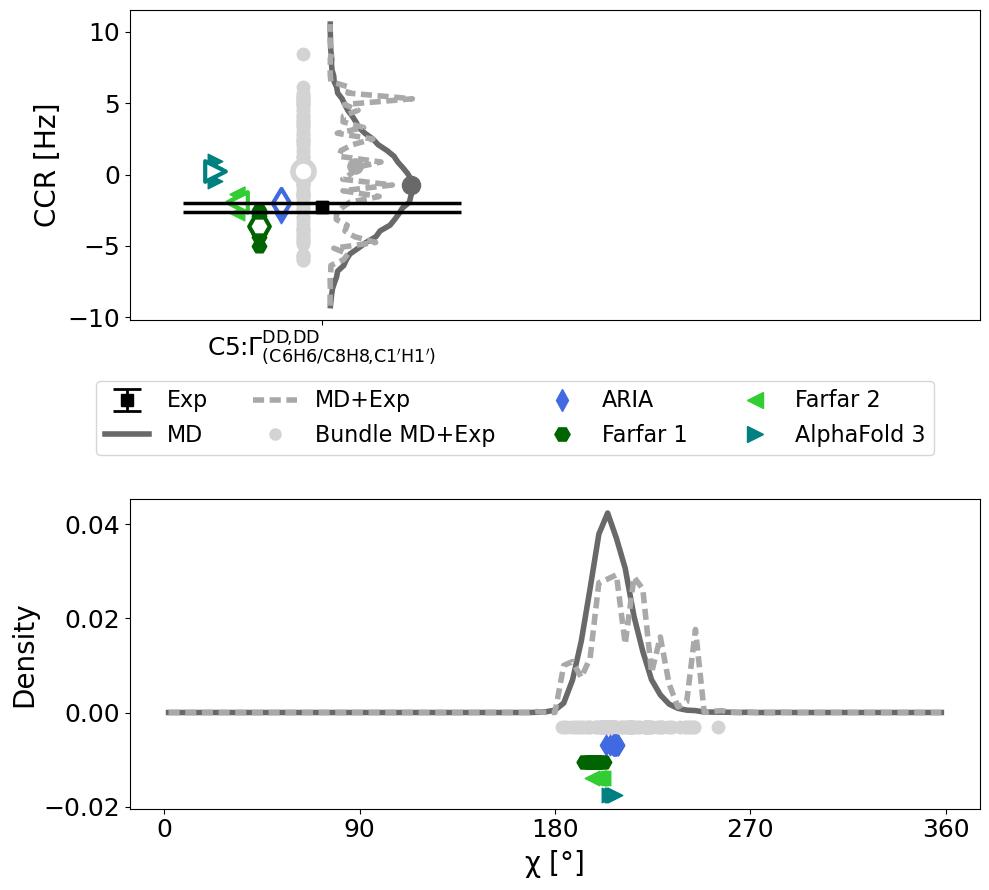

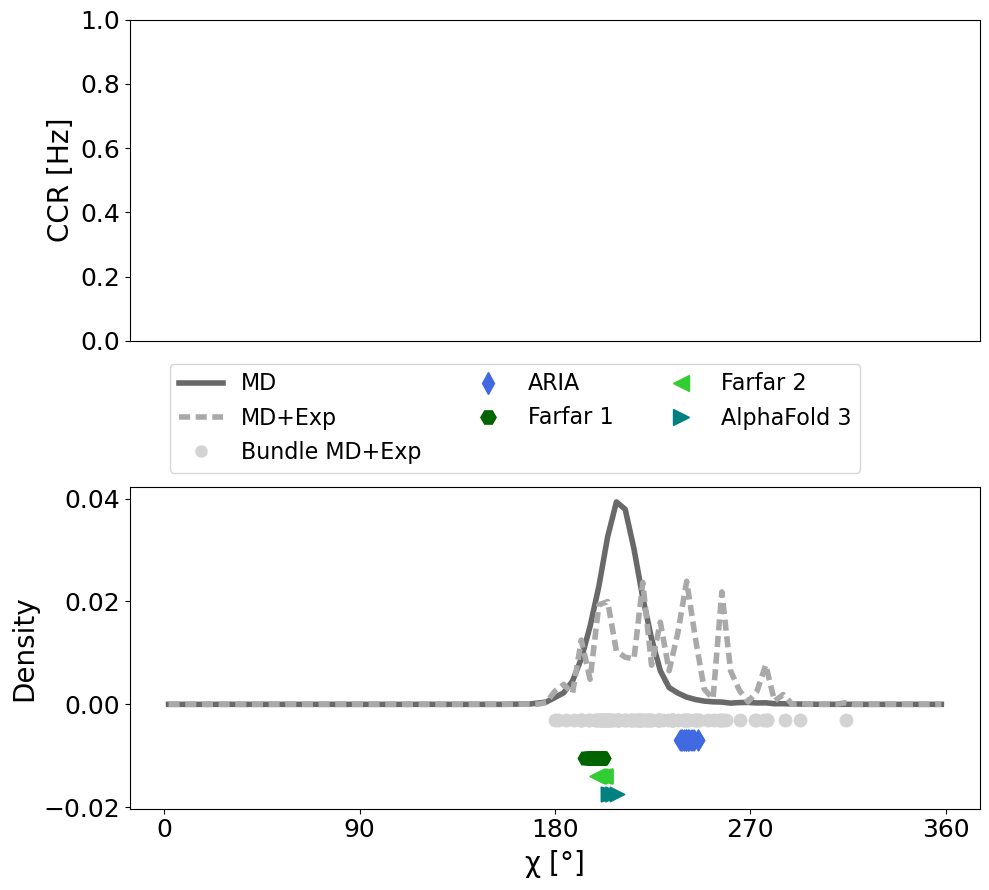

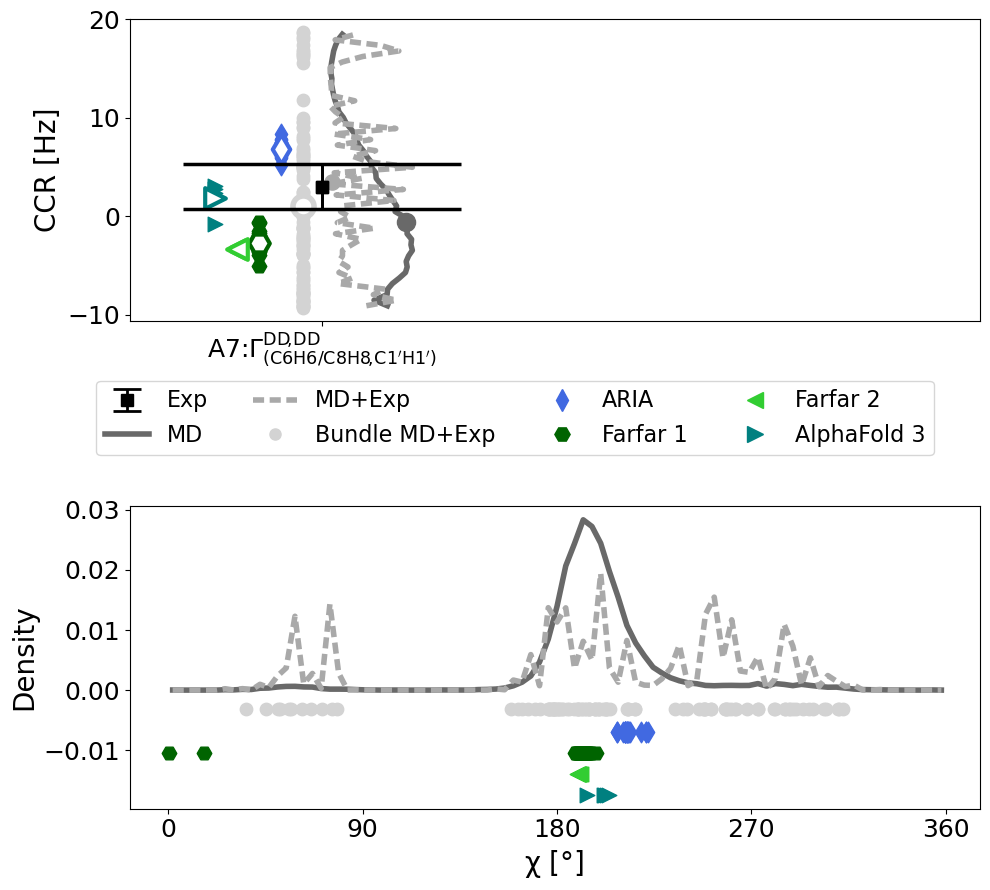

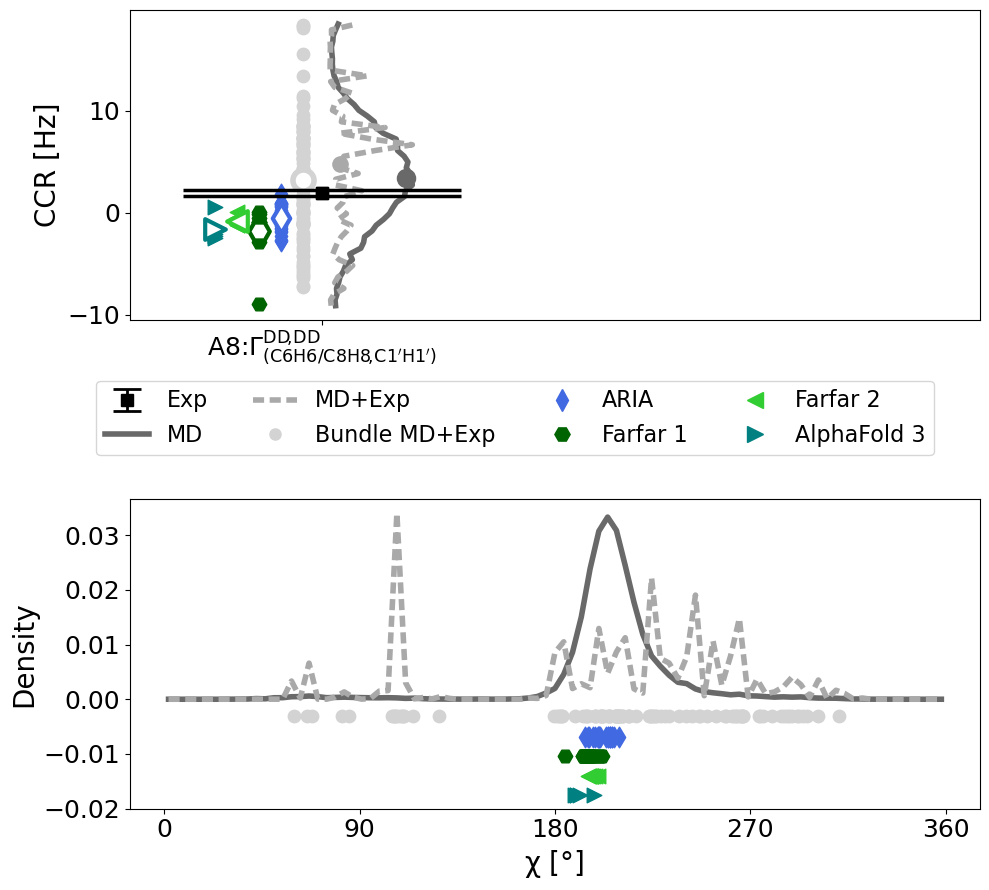

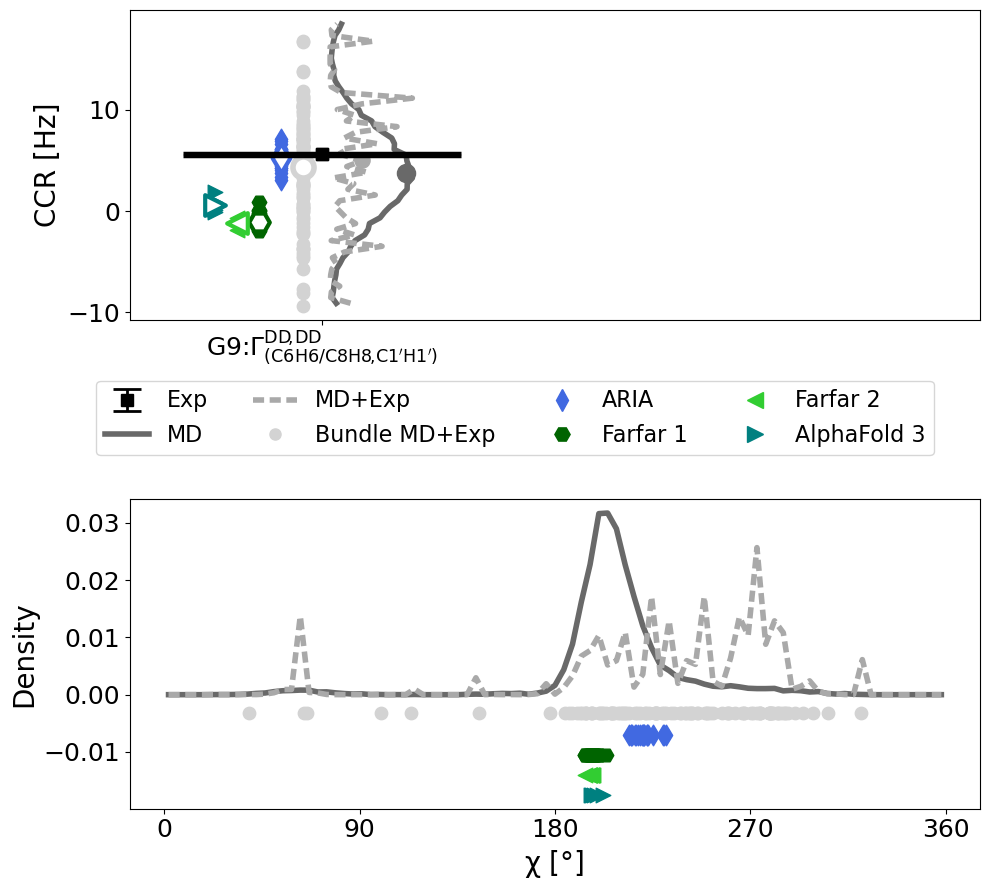

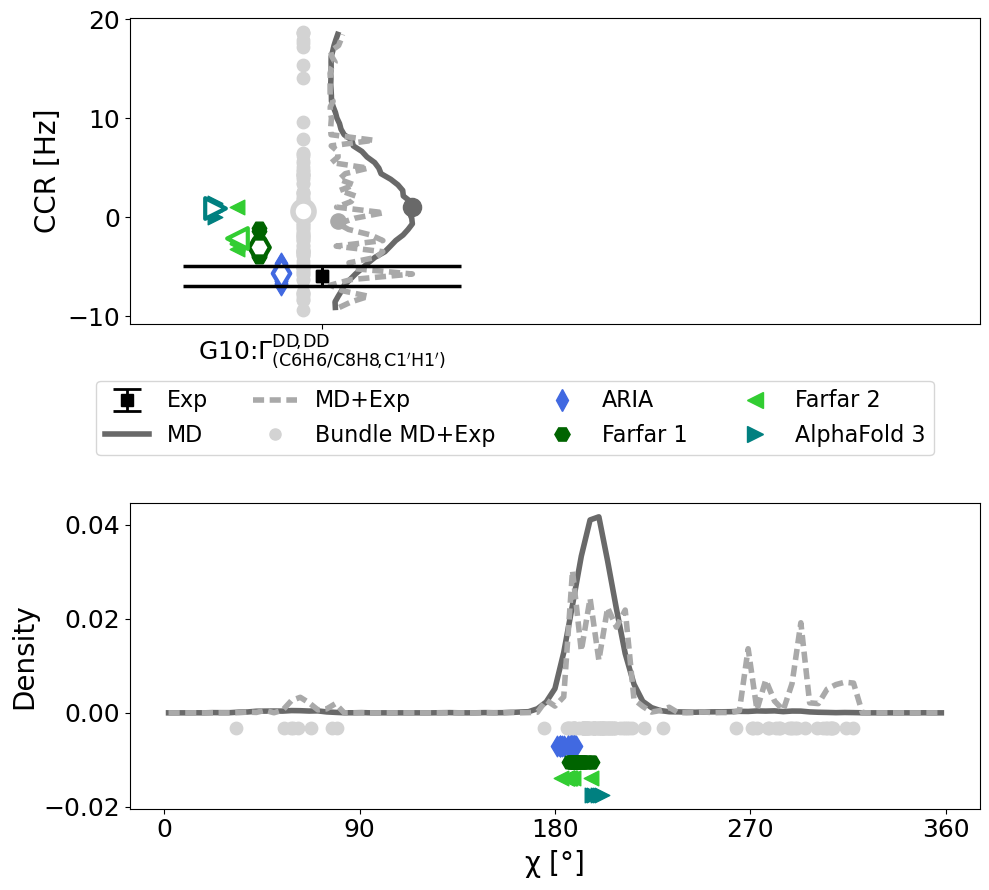

In [31]:
for i,r in enumerate(loop_res):
    plot_angle_measurement_si(r, 'chi', ["C1-CC"], 'hcn', save=True)    

## $\alpha$

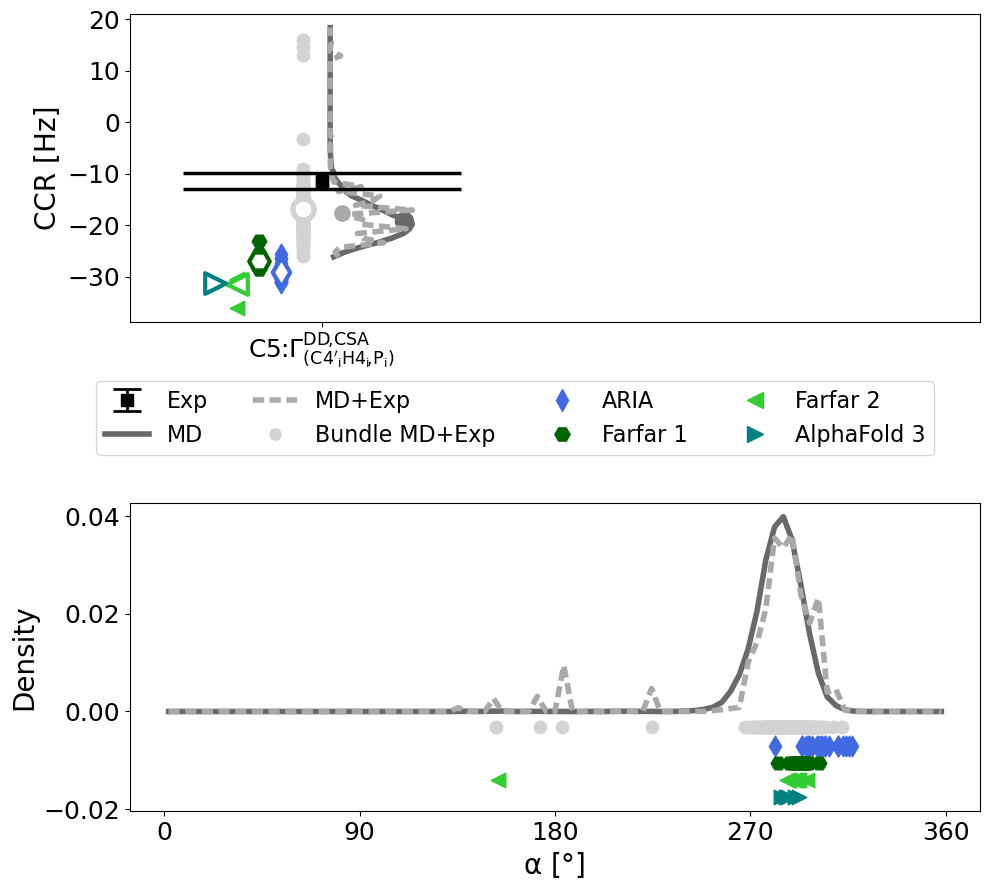

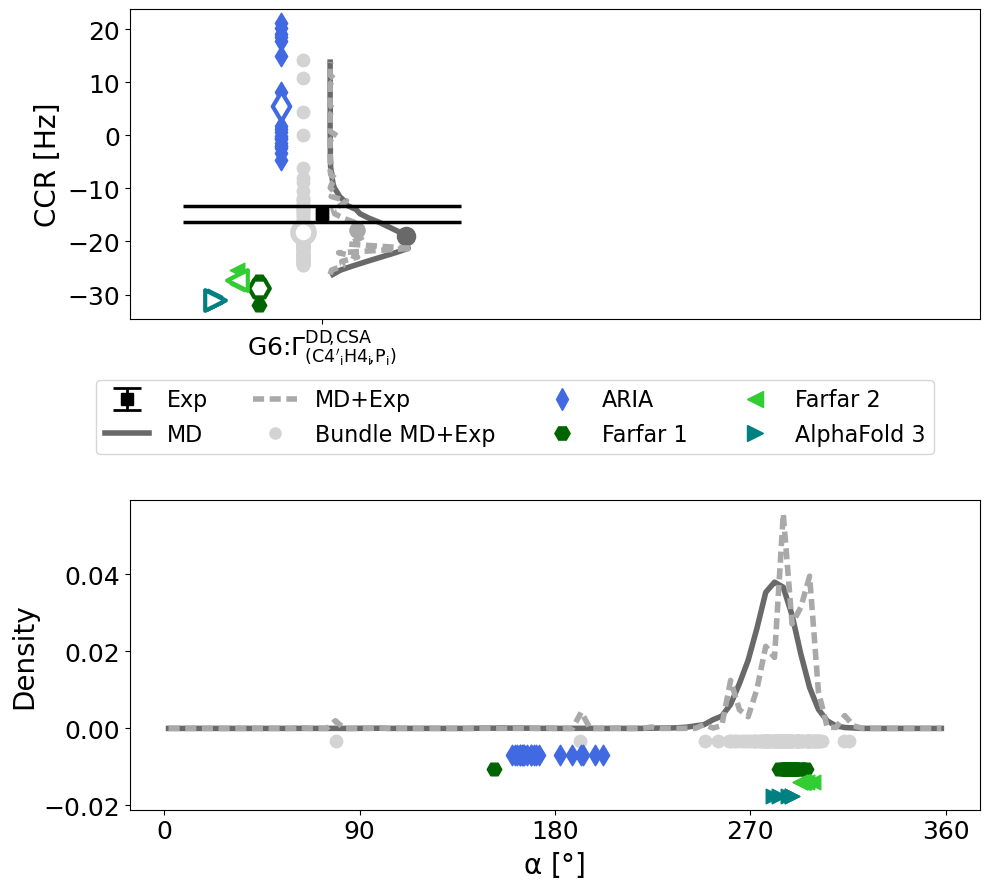

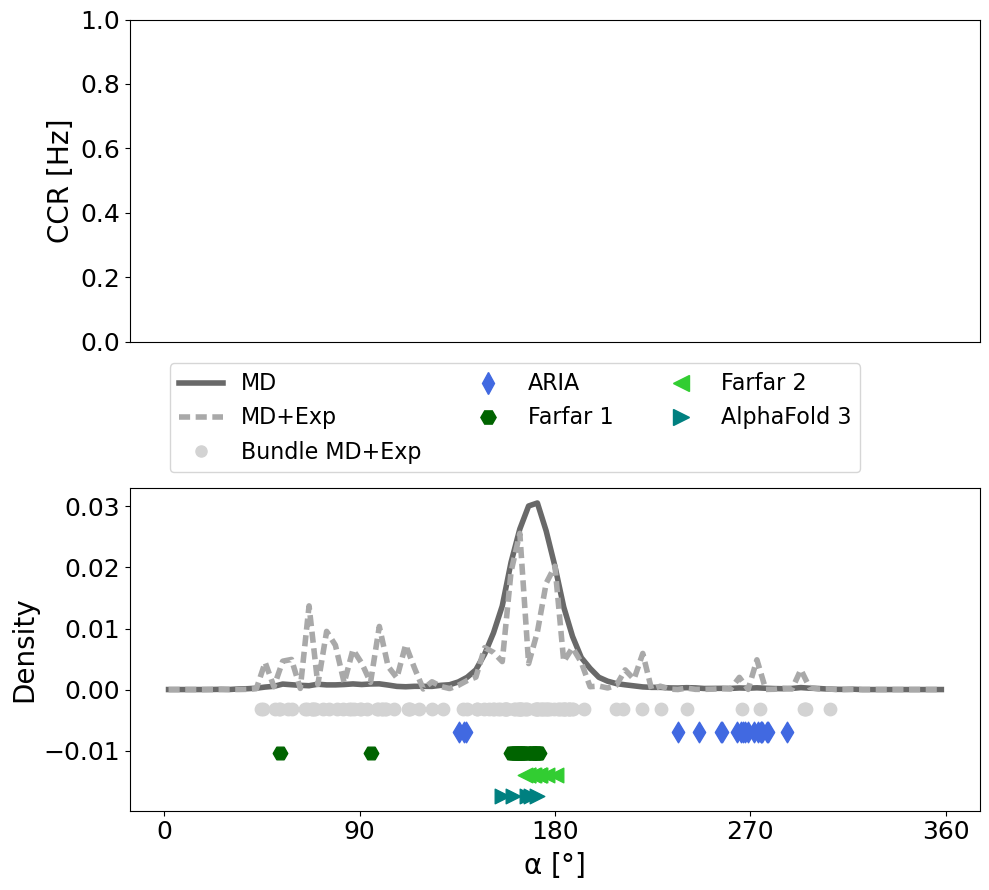

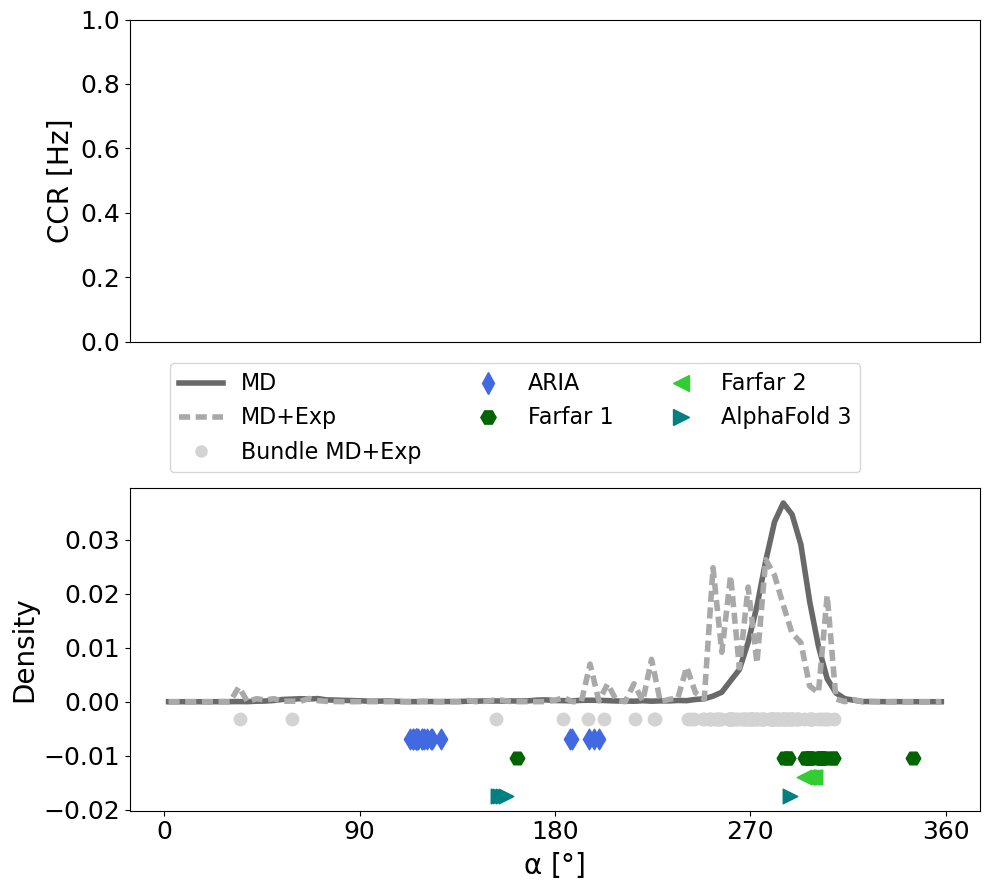

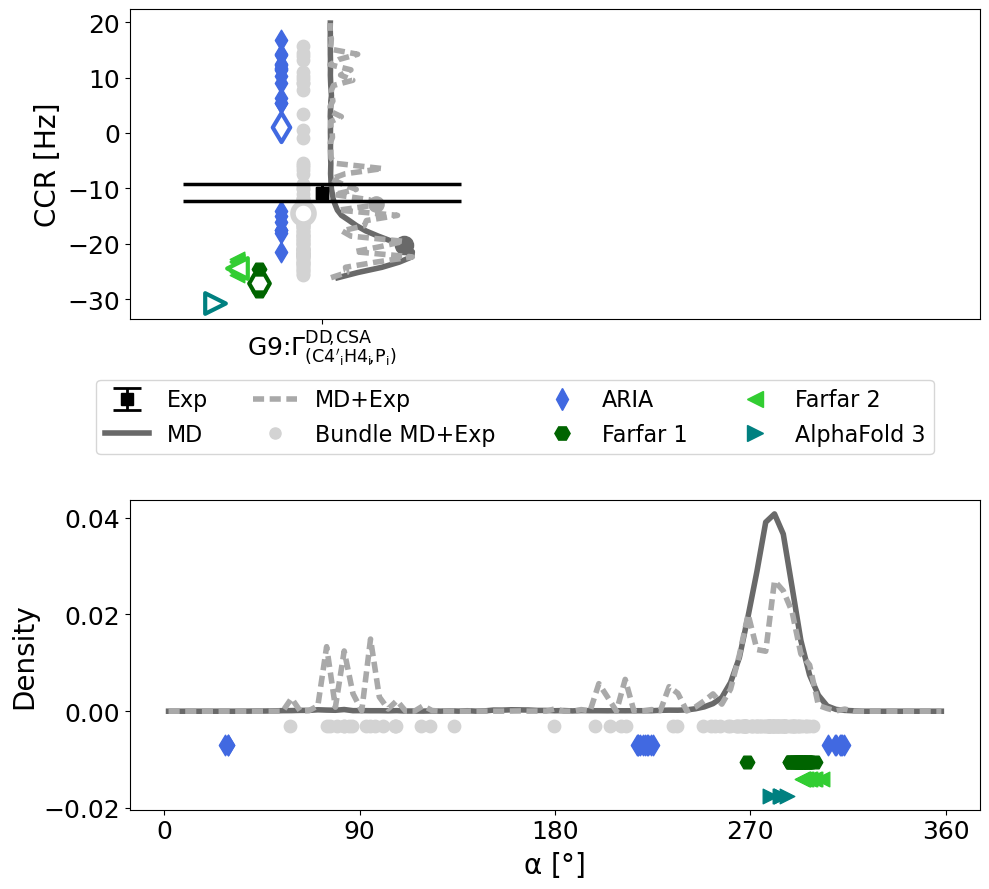

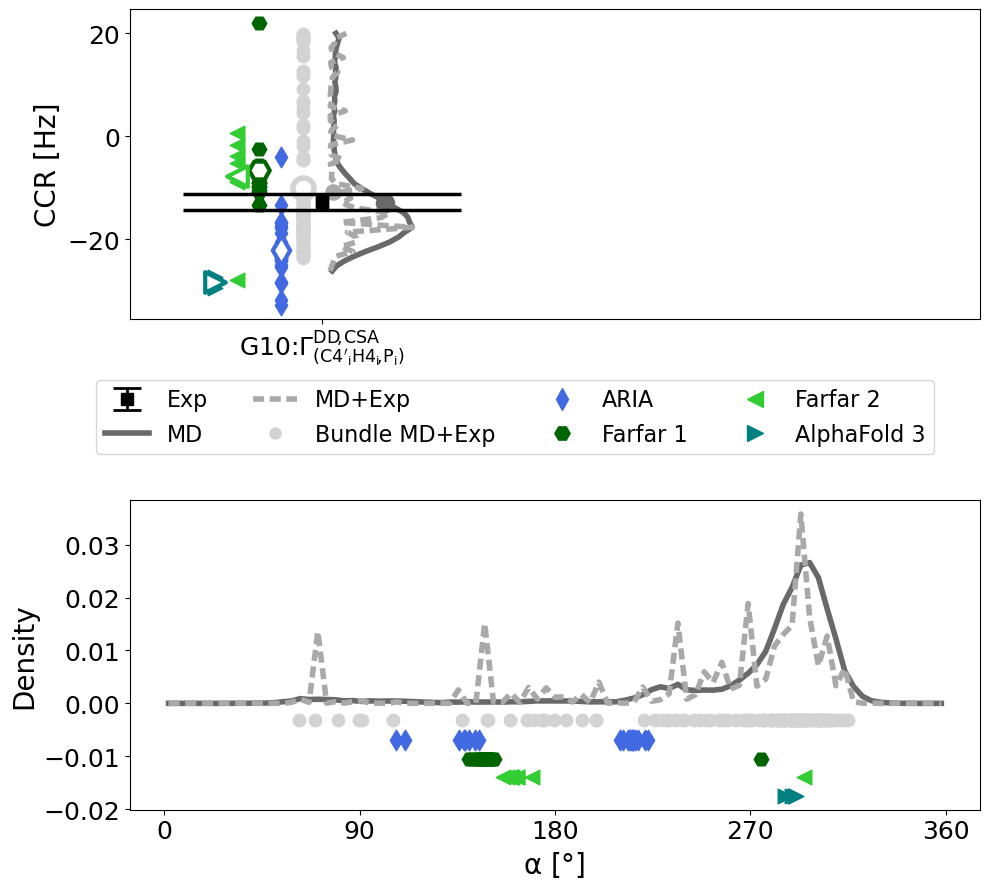

In [32]:
for i,r in enumerate(loop_res):
    plot_angle_measurement_si(r, 'alpha', ['C4p-P'], 'hcp', save=True)

## $\beta$

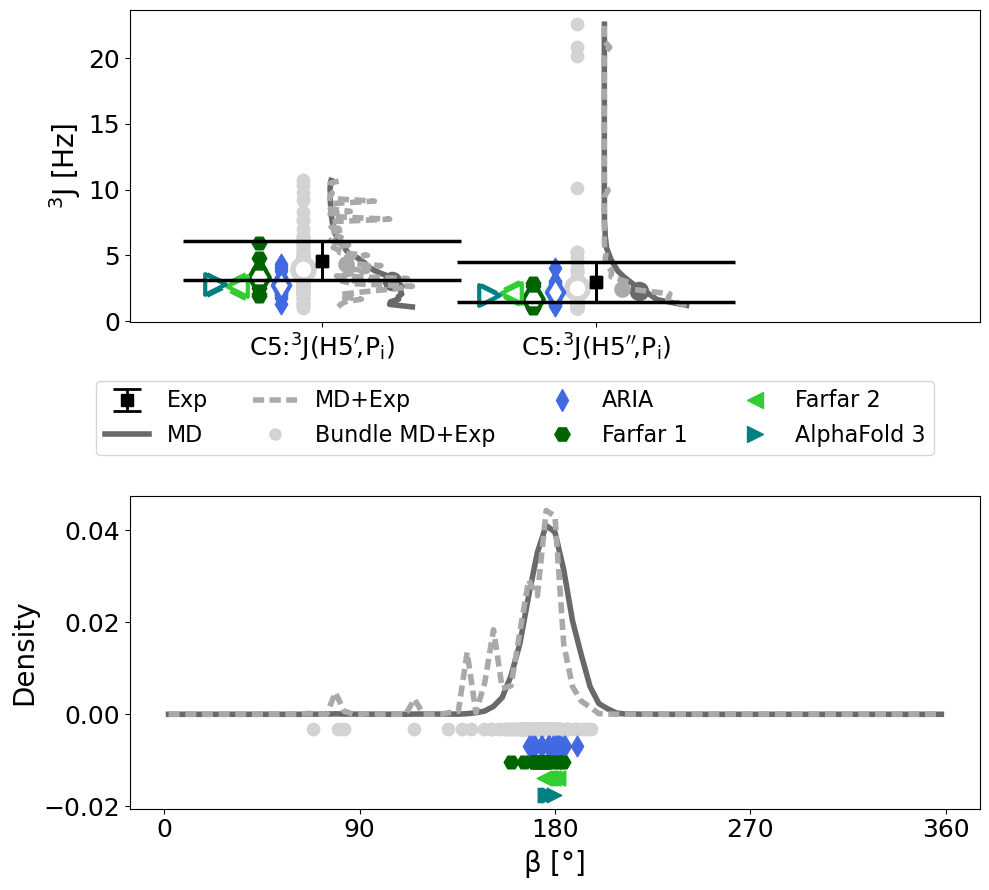

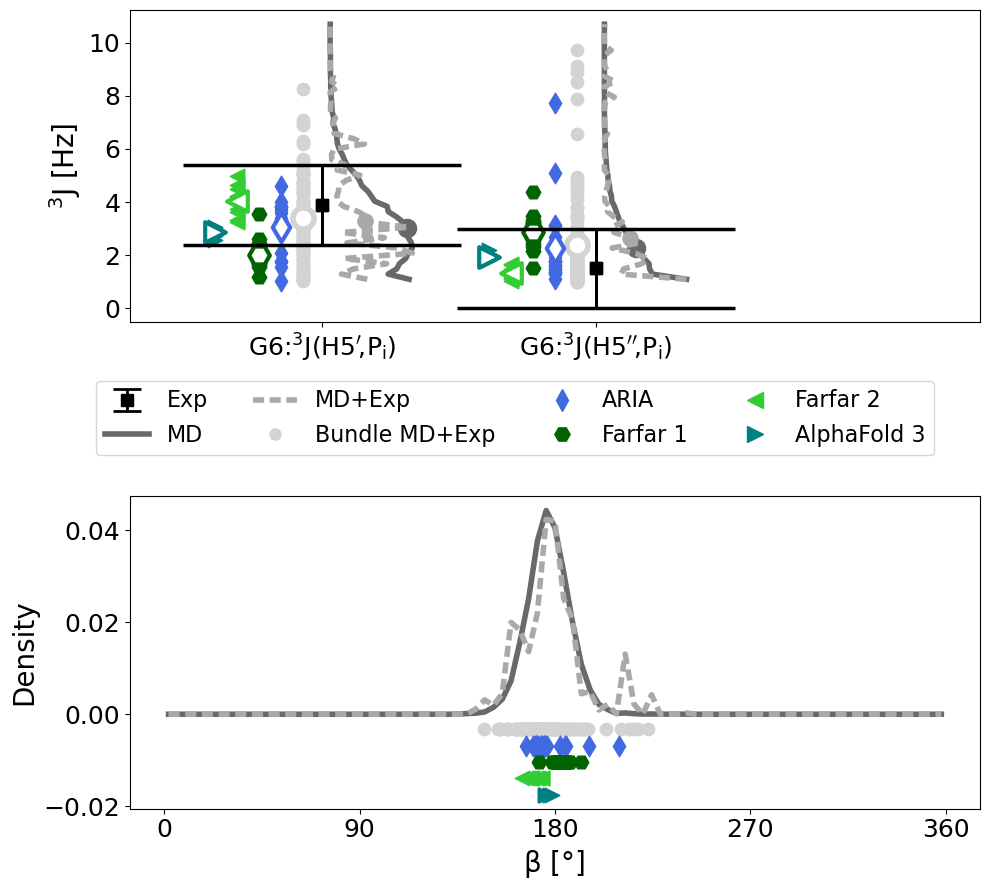

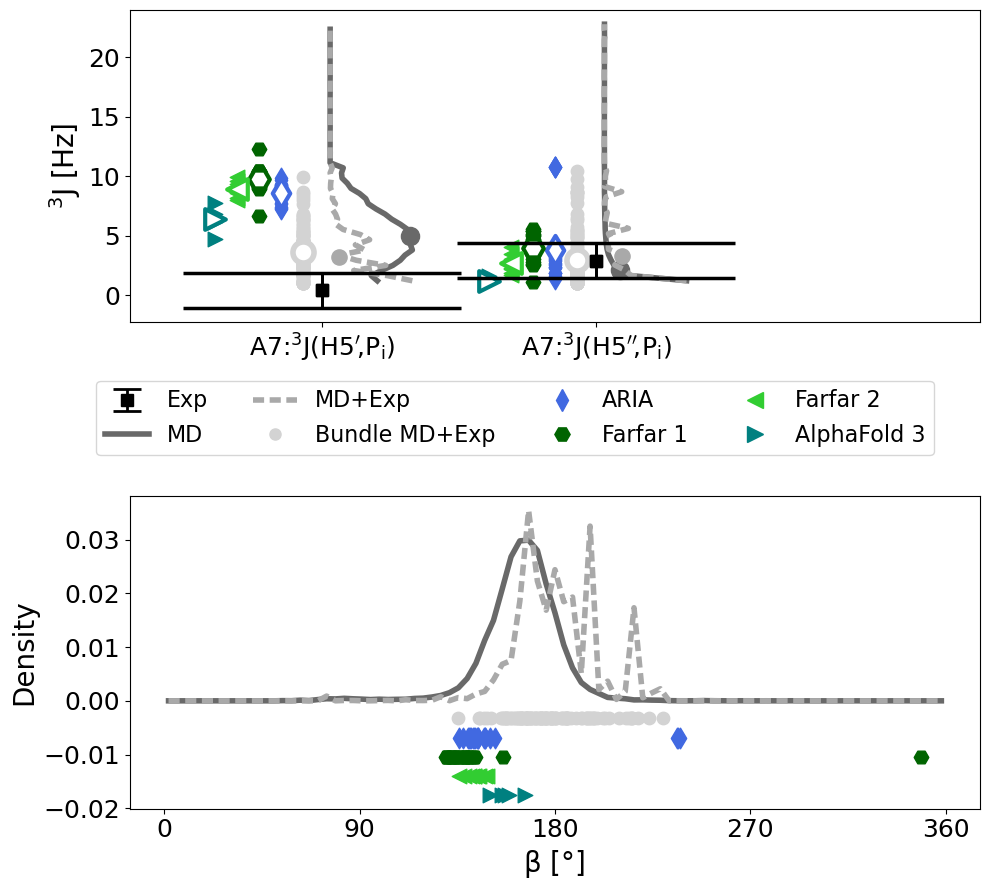

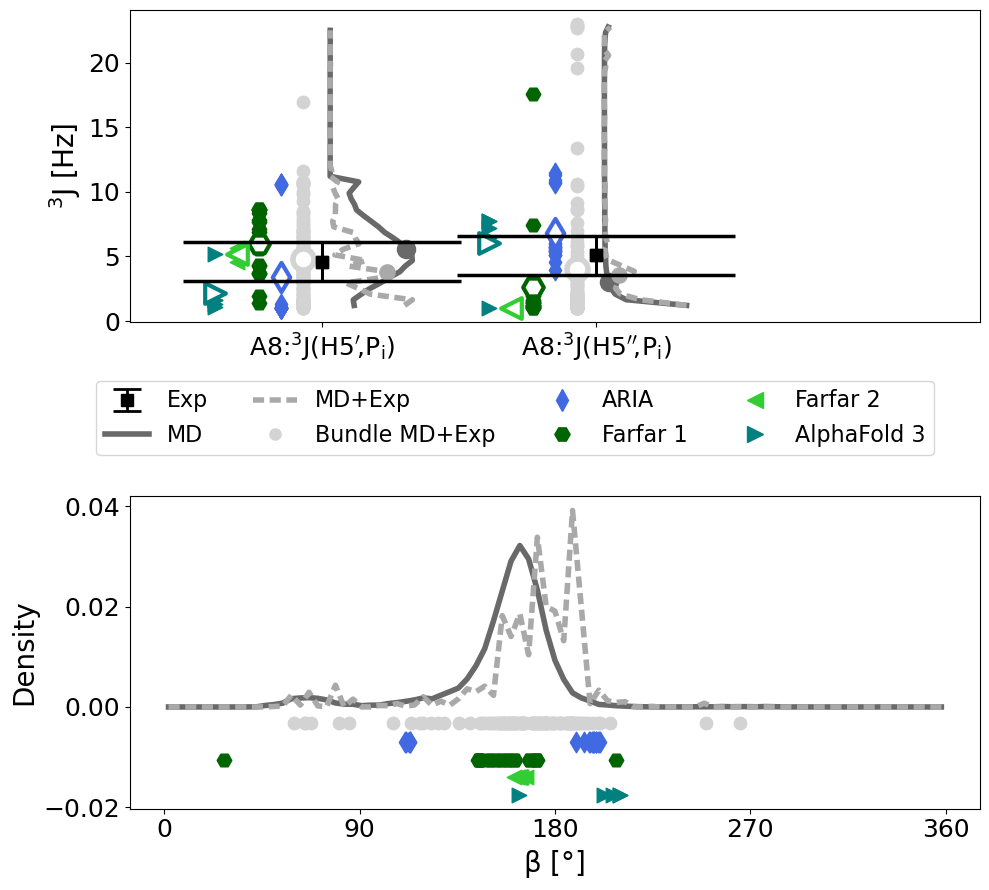

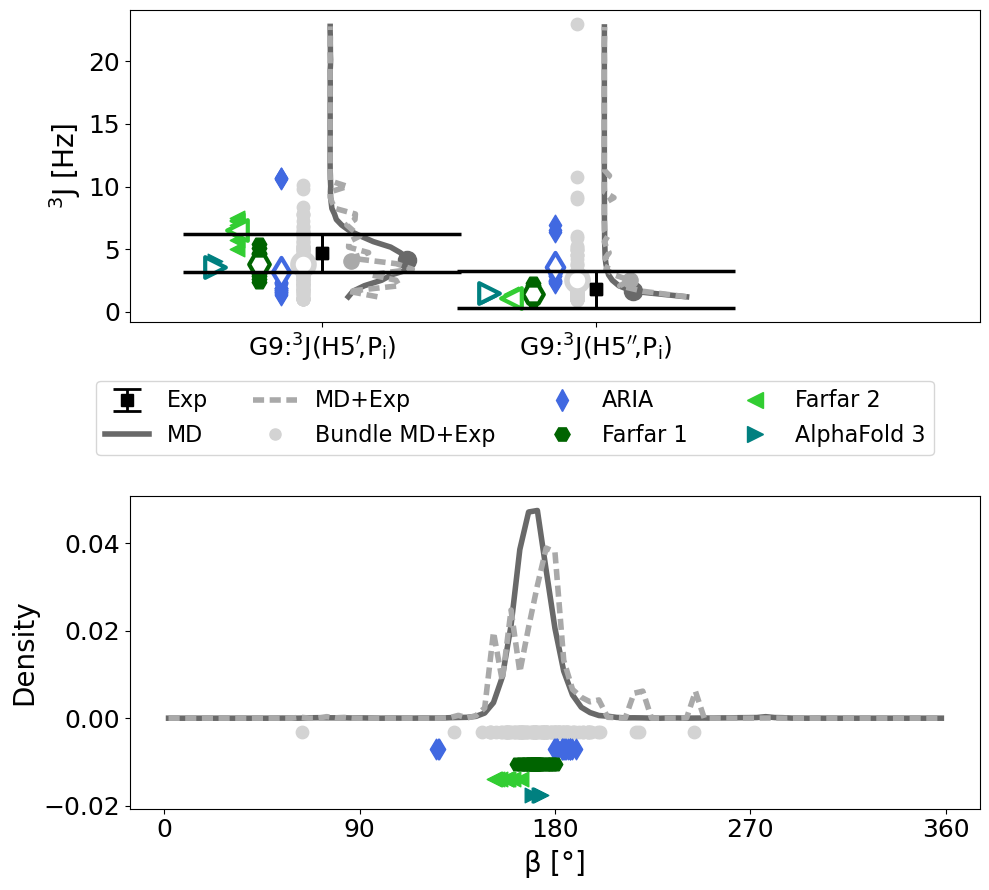

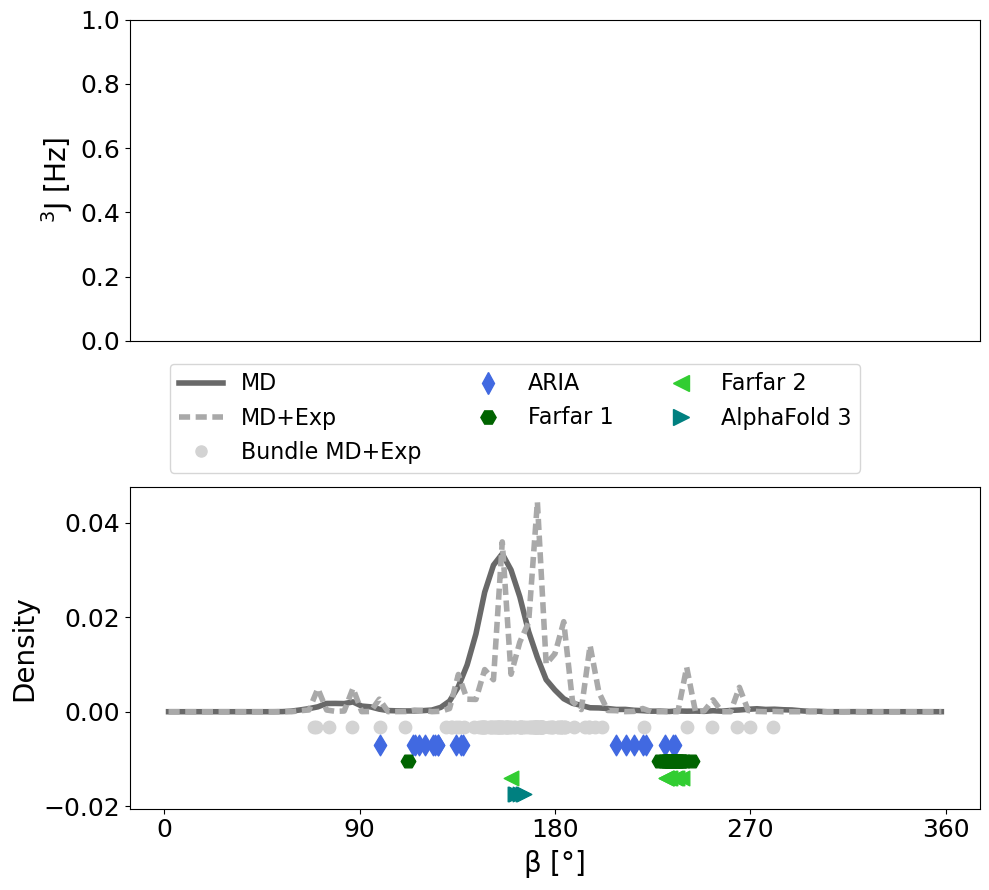

In [33]:
for i,r in enumerate(loop_res):
    plot_angle_measurement_si(r, 'beta', ['C4Pb', '1H5P', '2H5P'], 'j3', save=True)

## $\gamma$

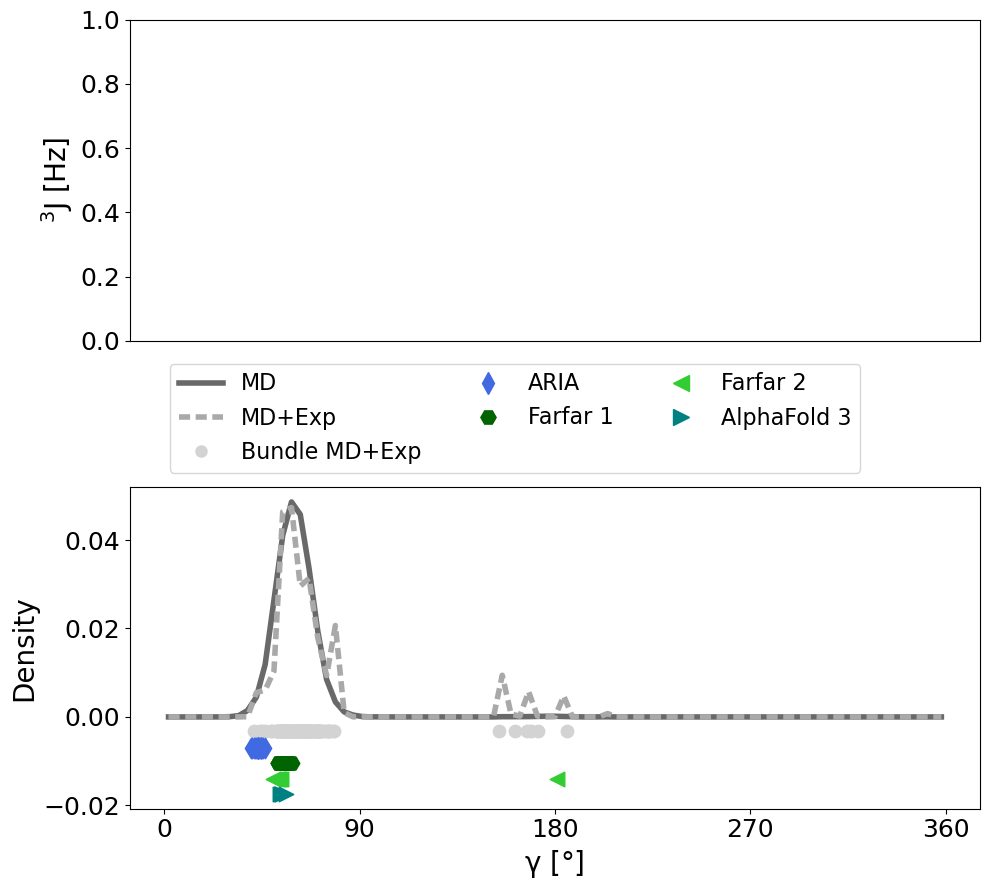

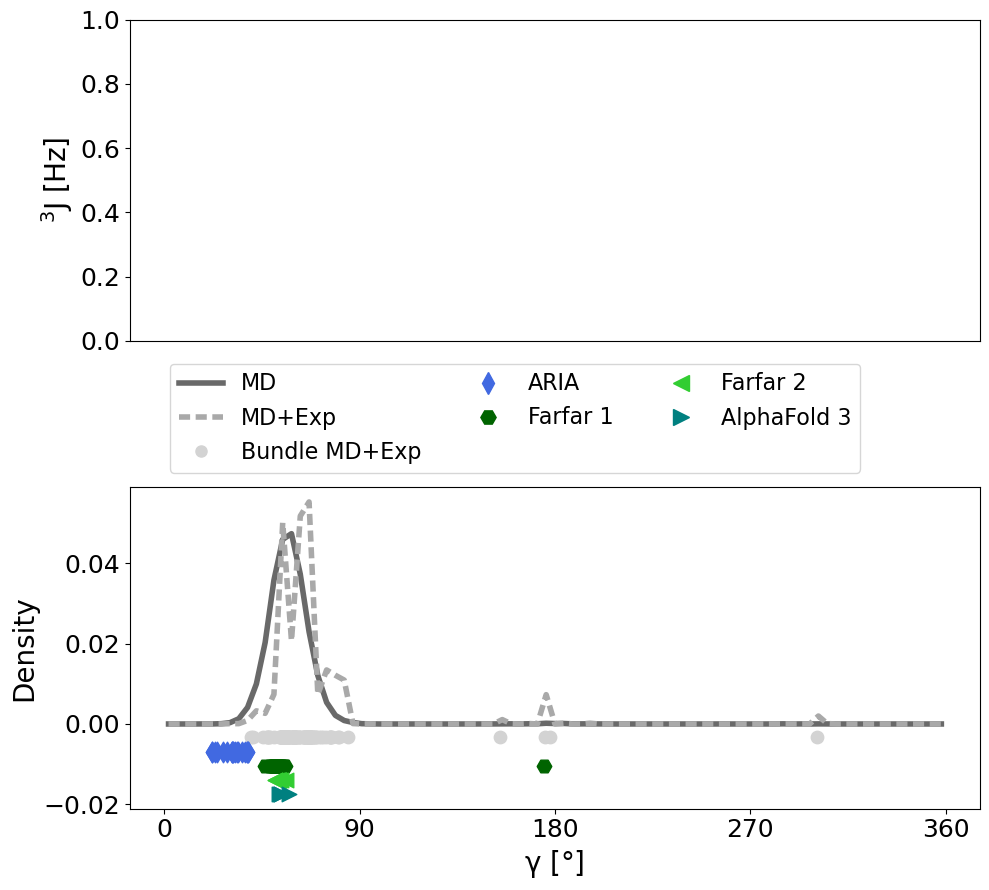

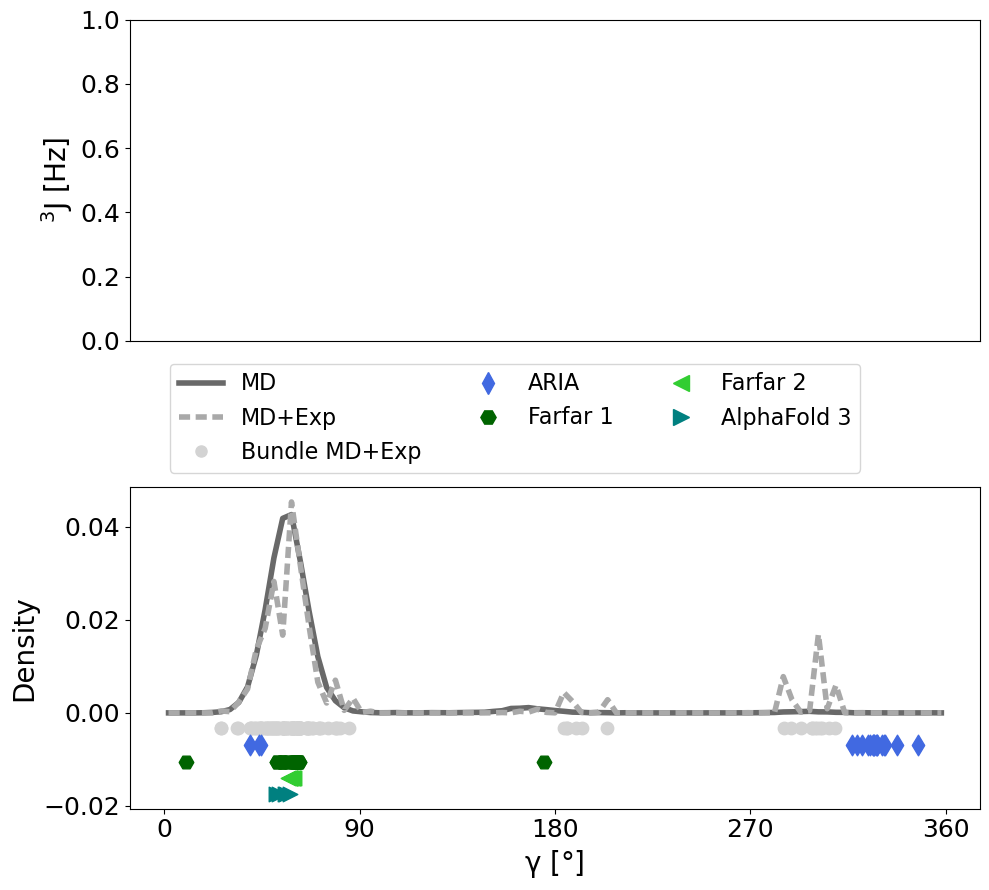

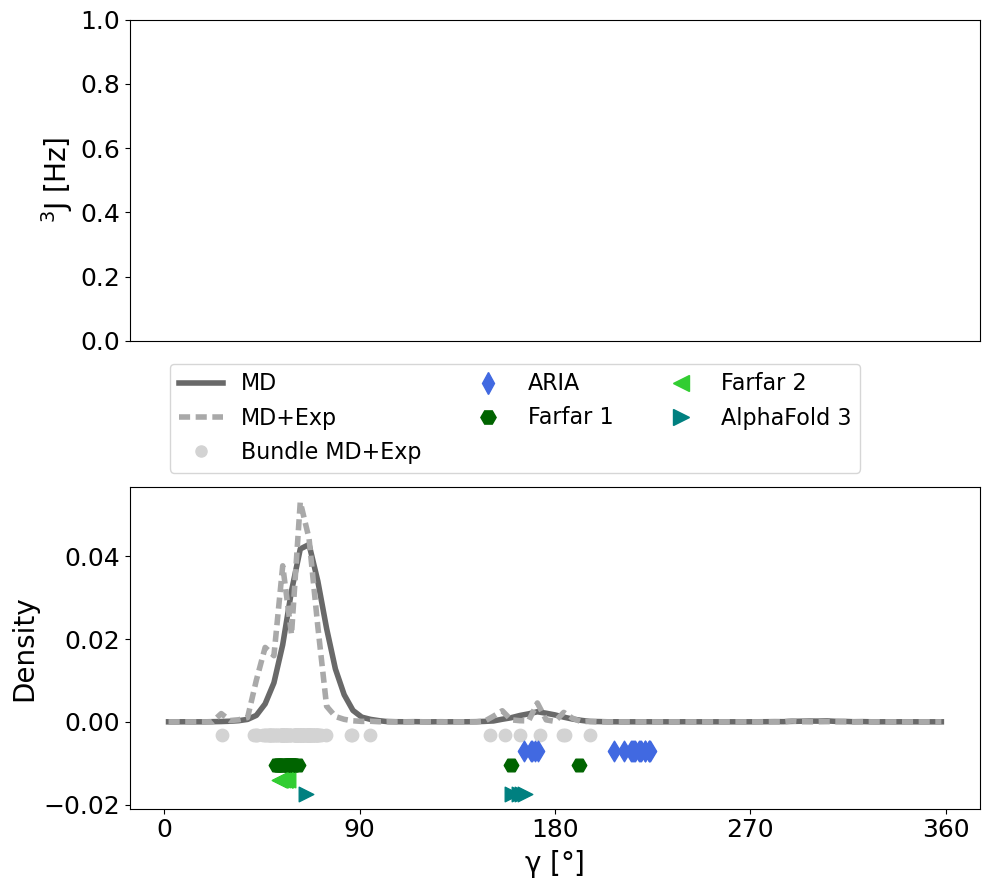

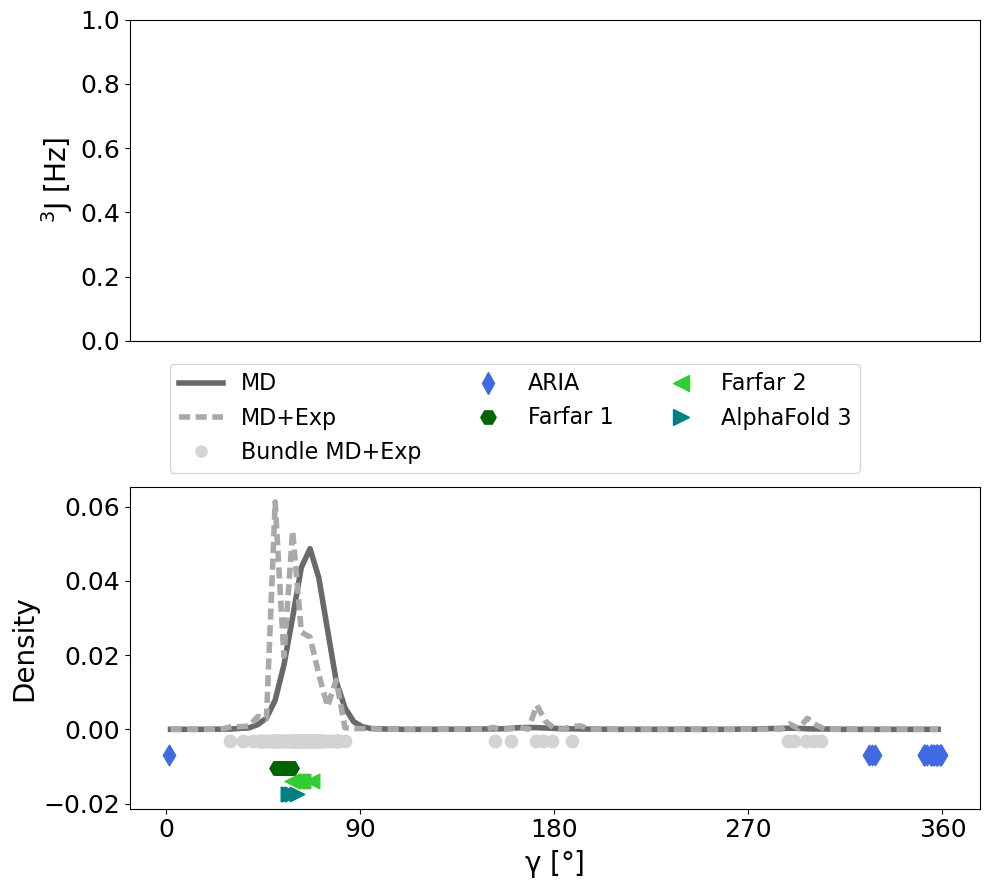

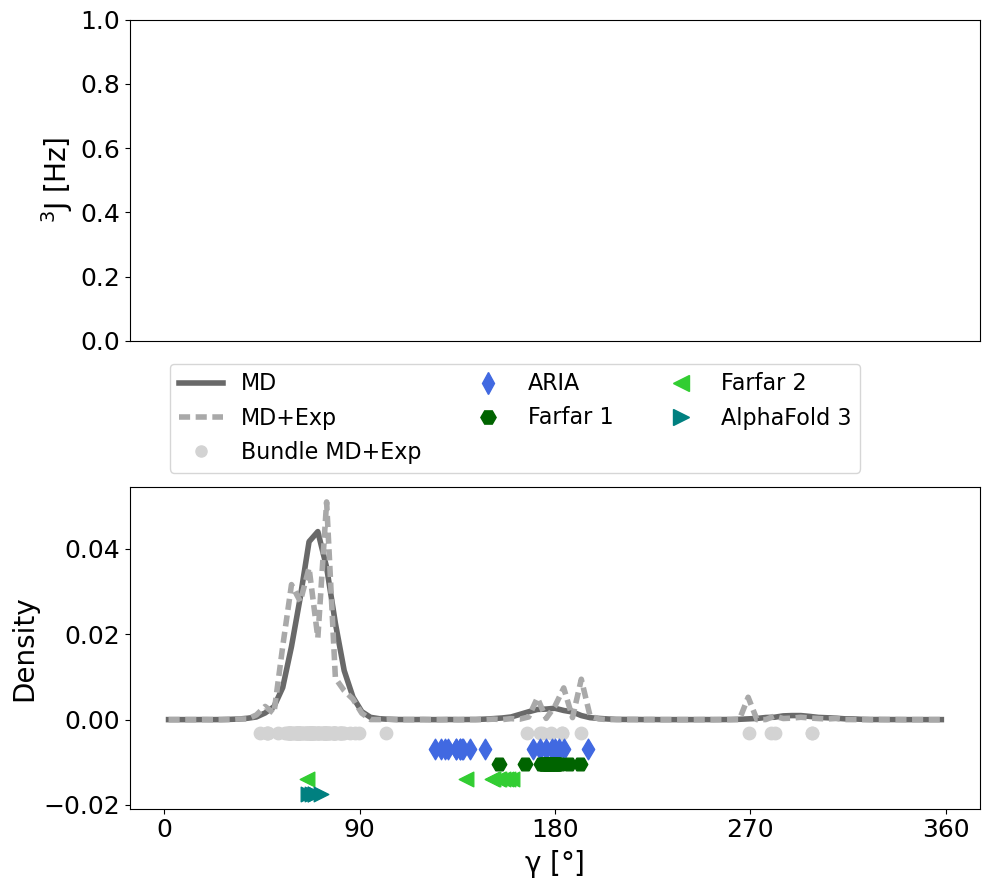

In [34]:
for i,r in enumerate(loop_res):
    plot_angle_measurement_si(r, 'gamma', ['1H5H4', '2H5H4'], 'j3', save=True)

## $\delta$

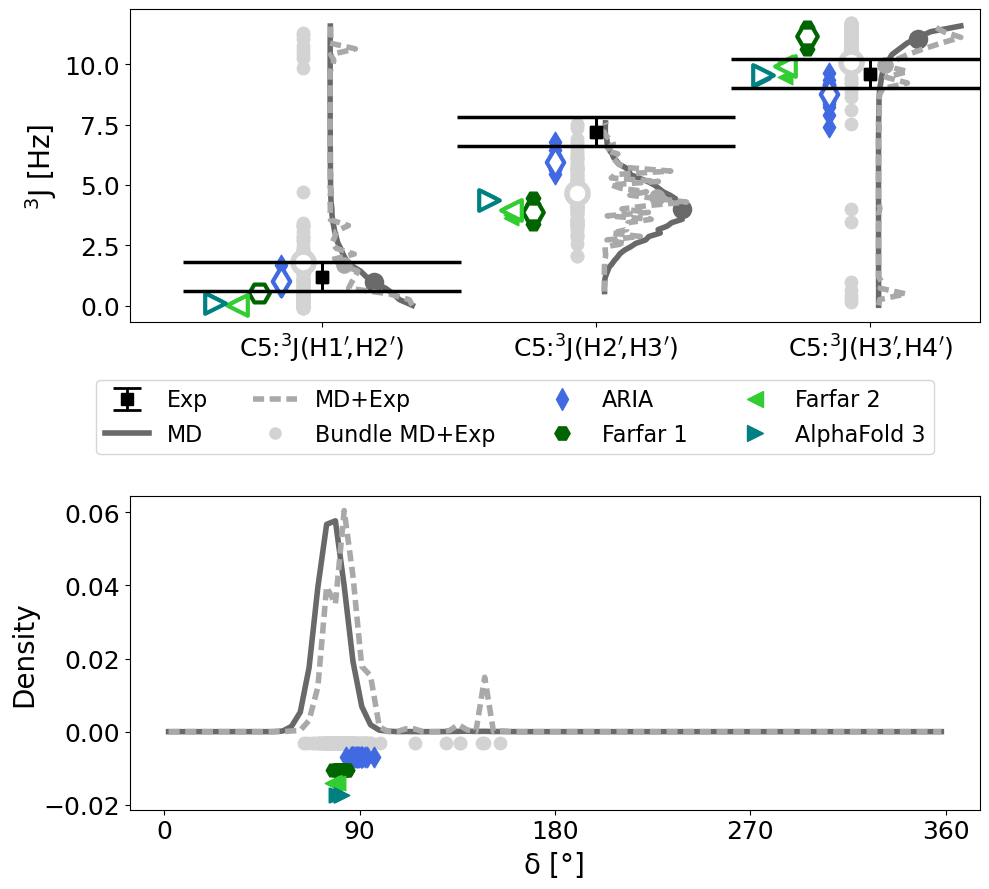

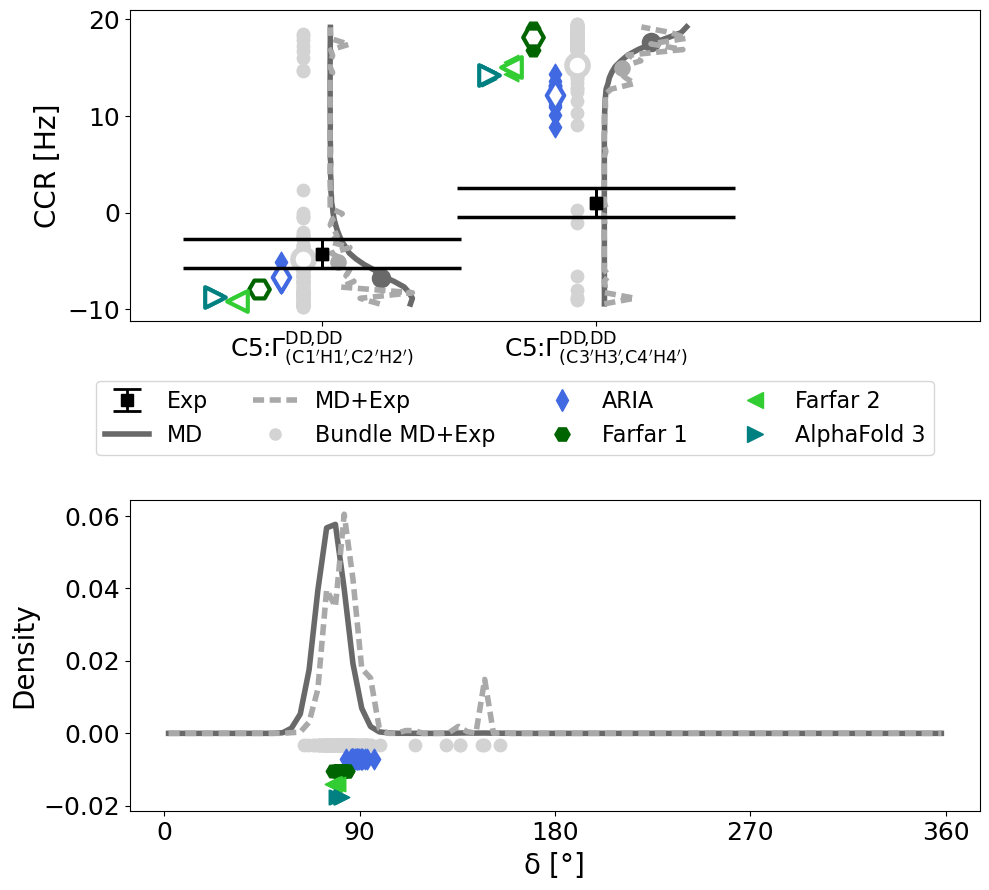

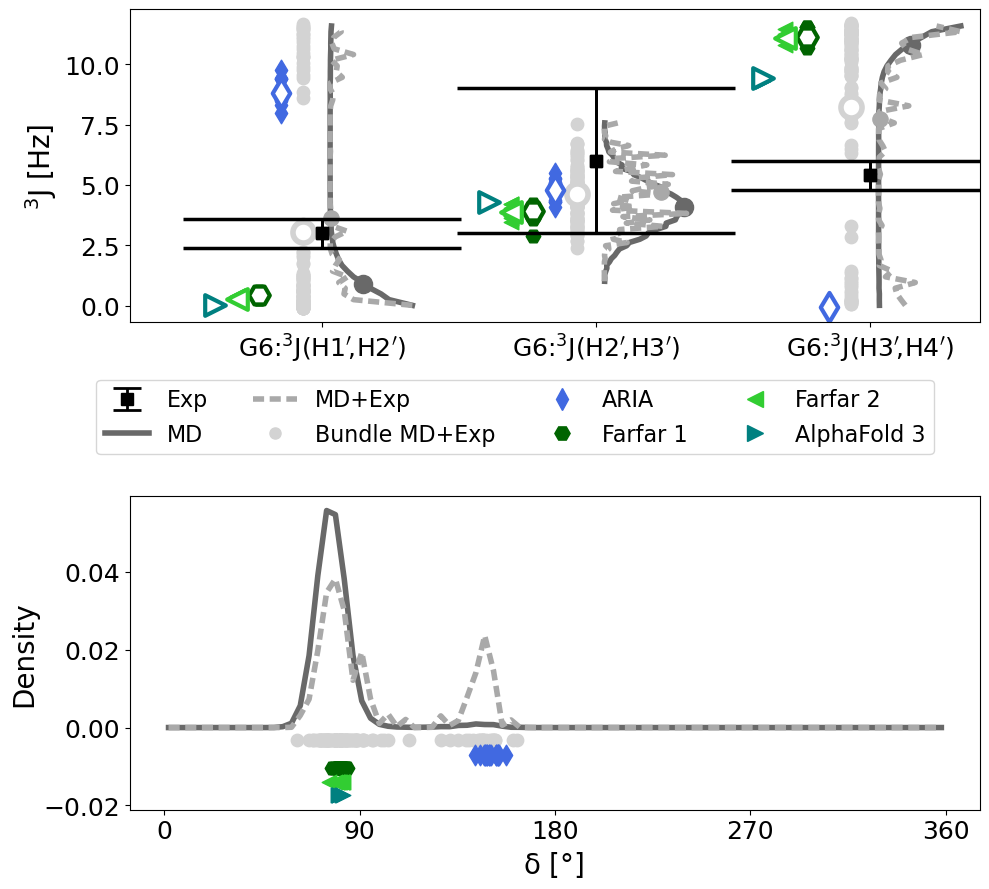

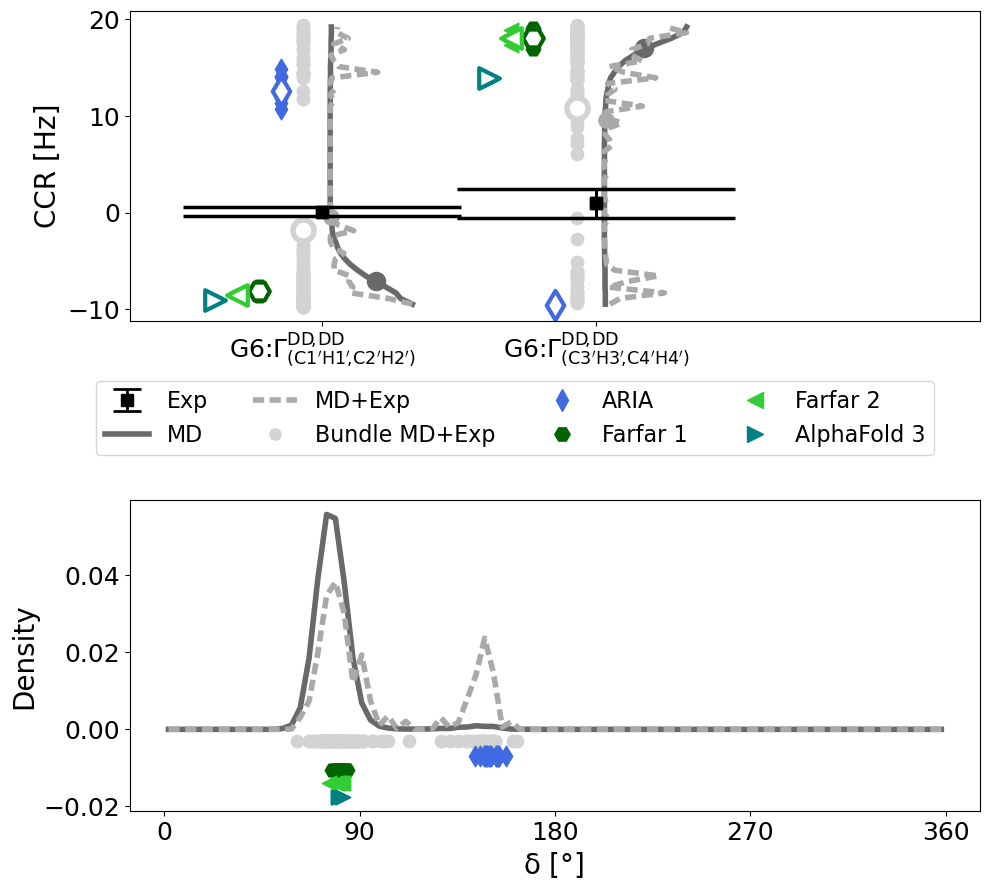

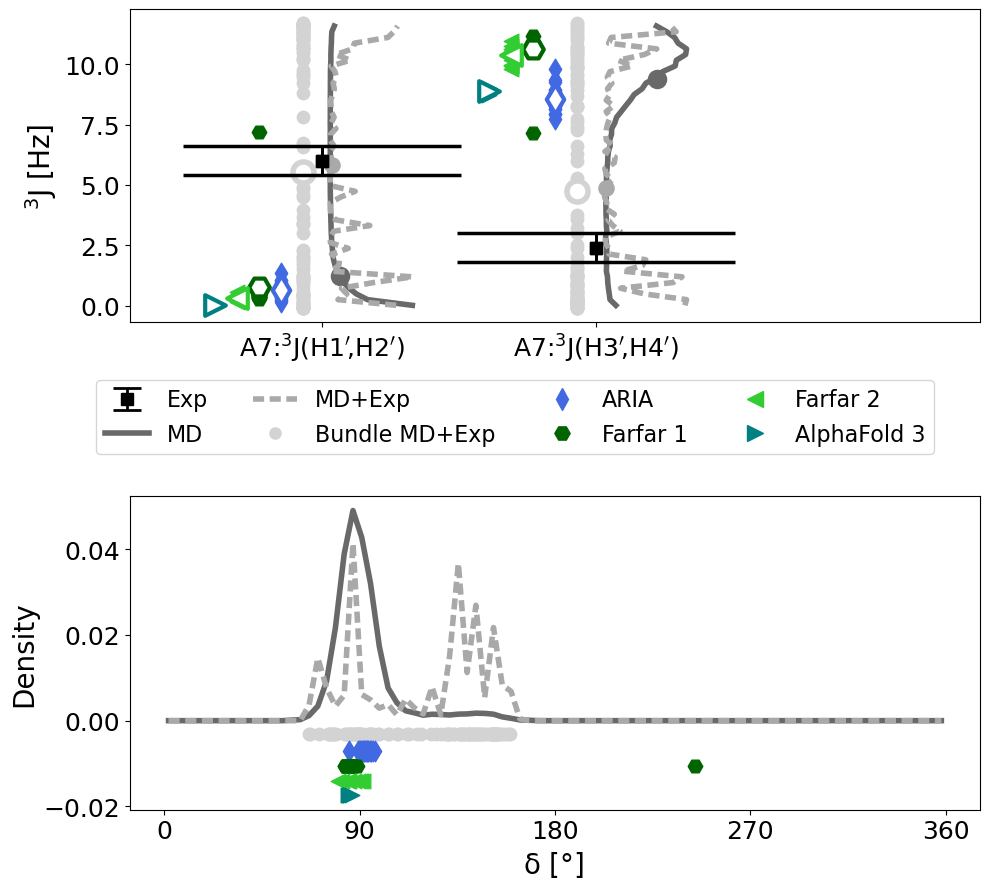

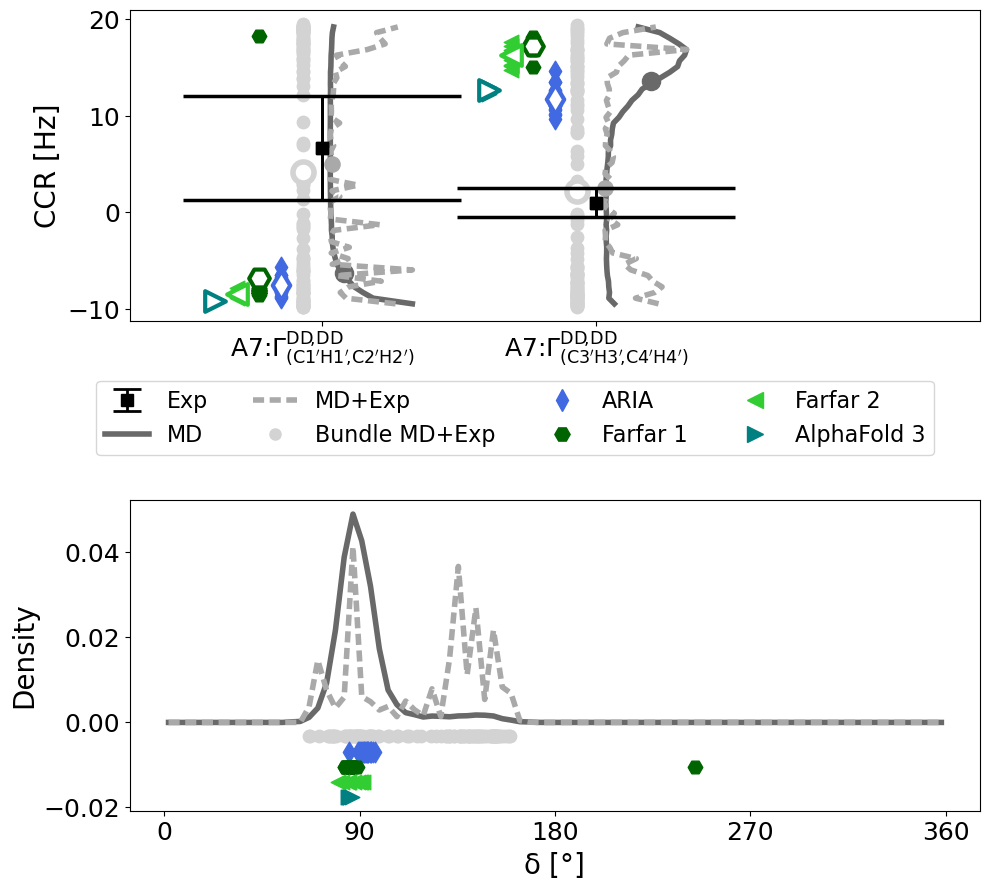

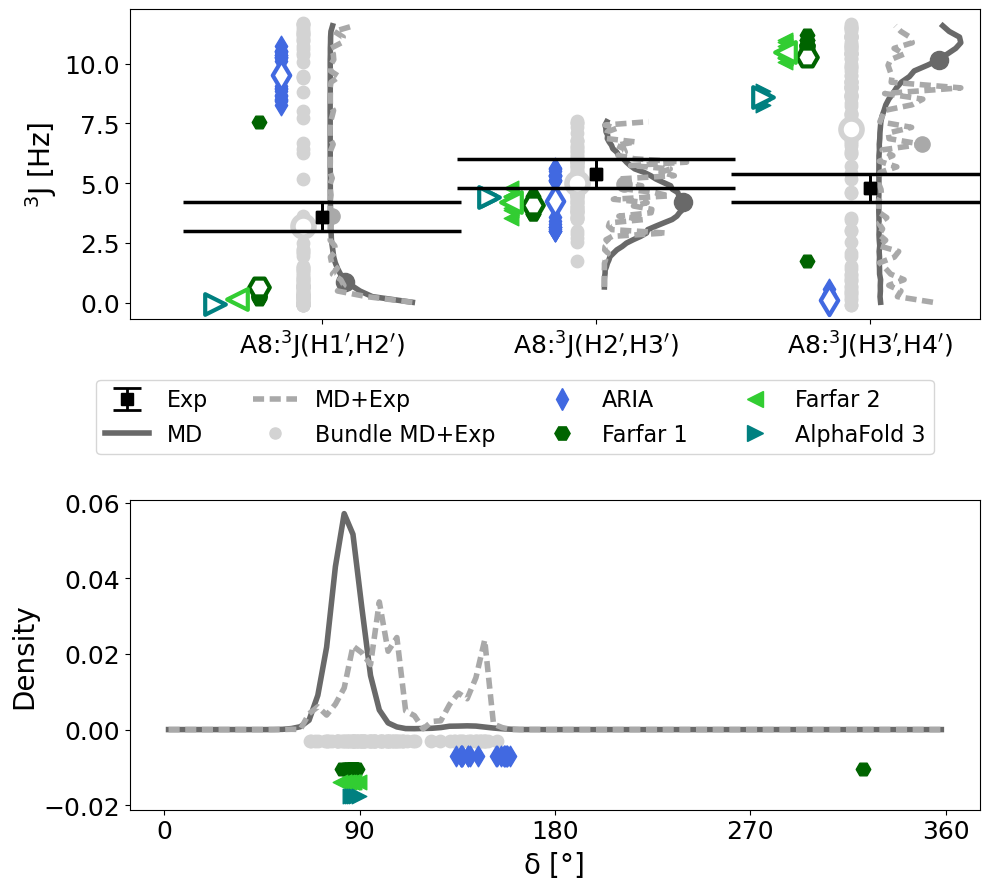

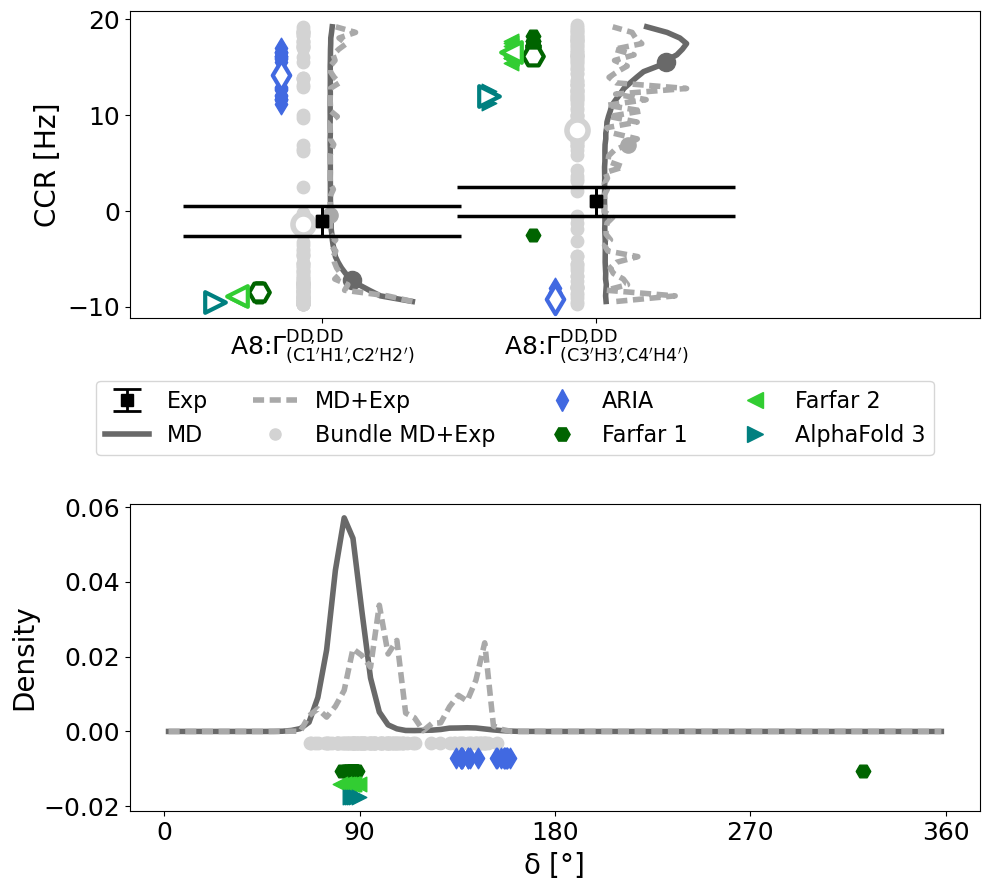

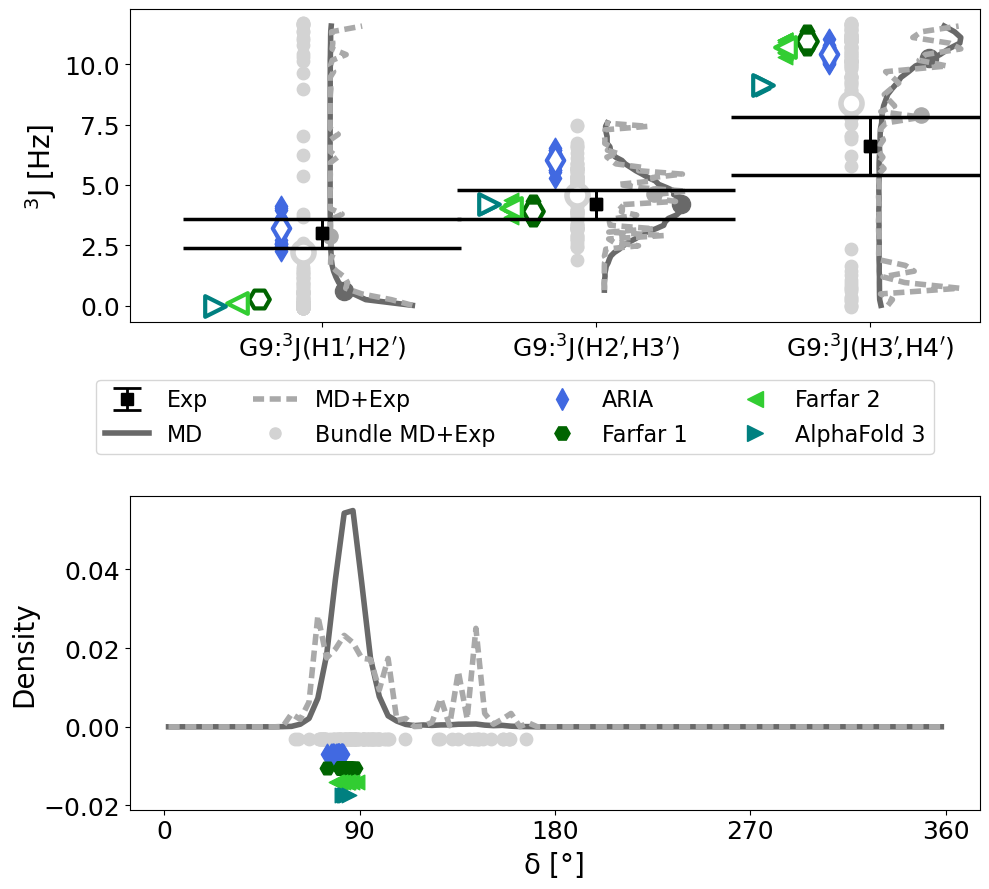

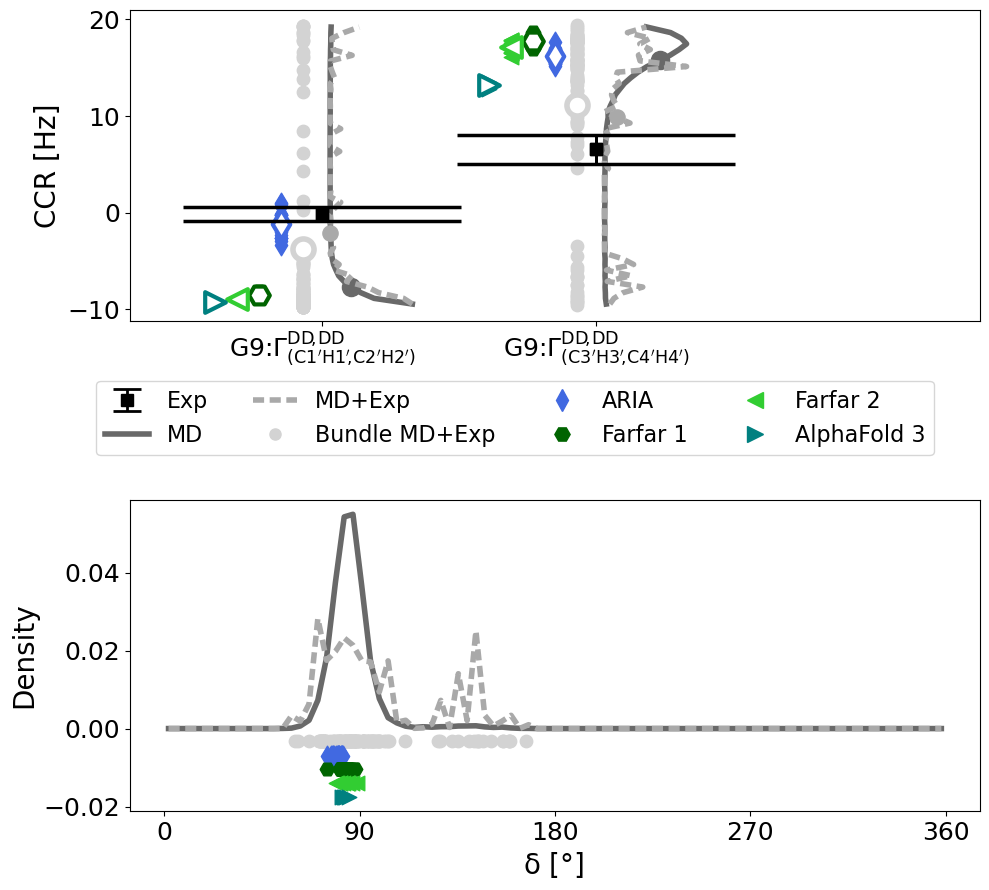

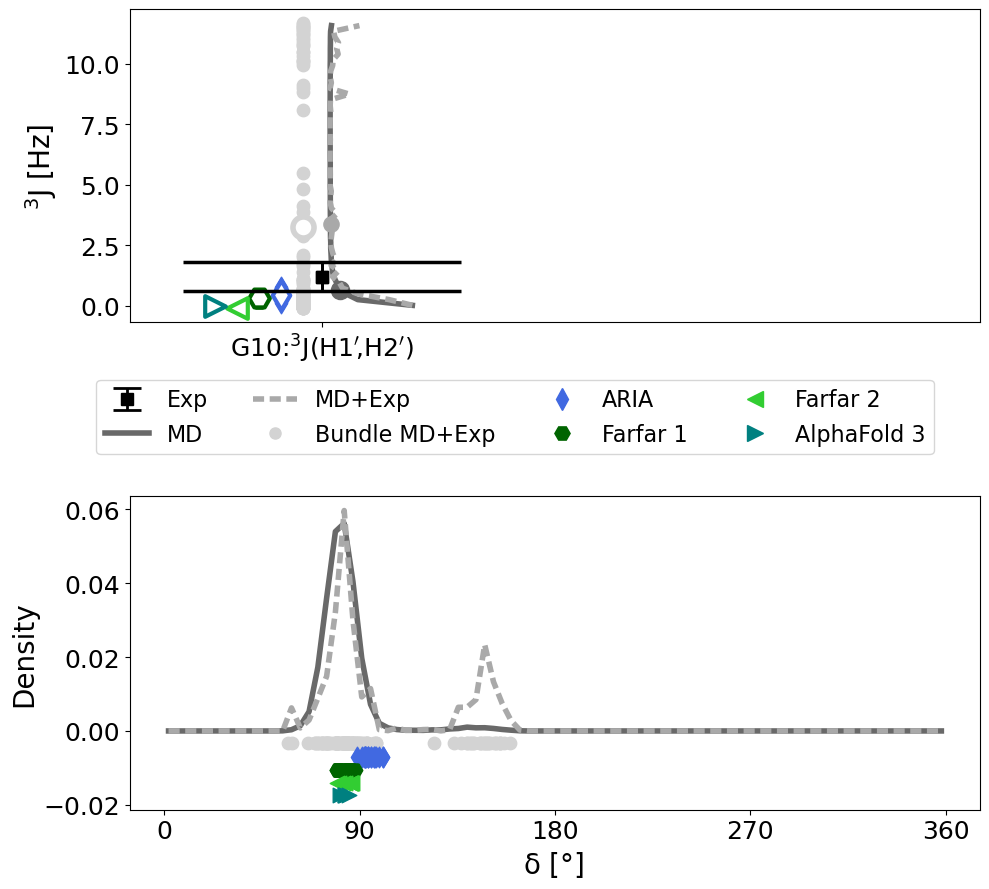

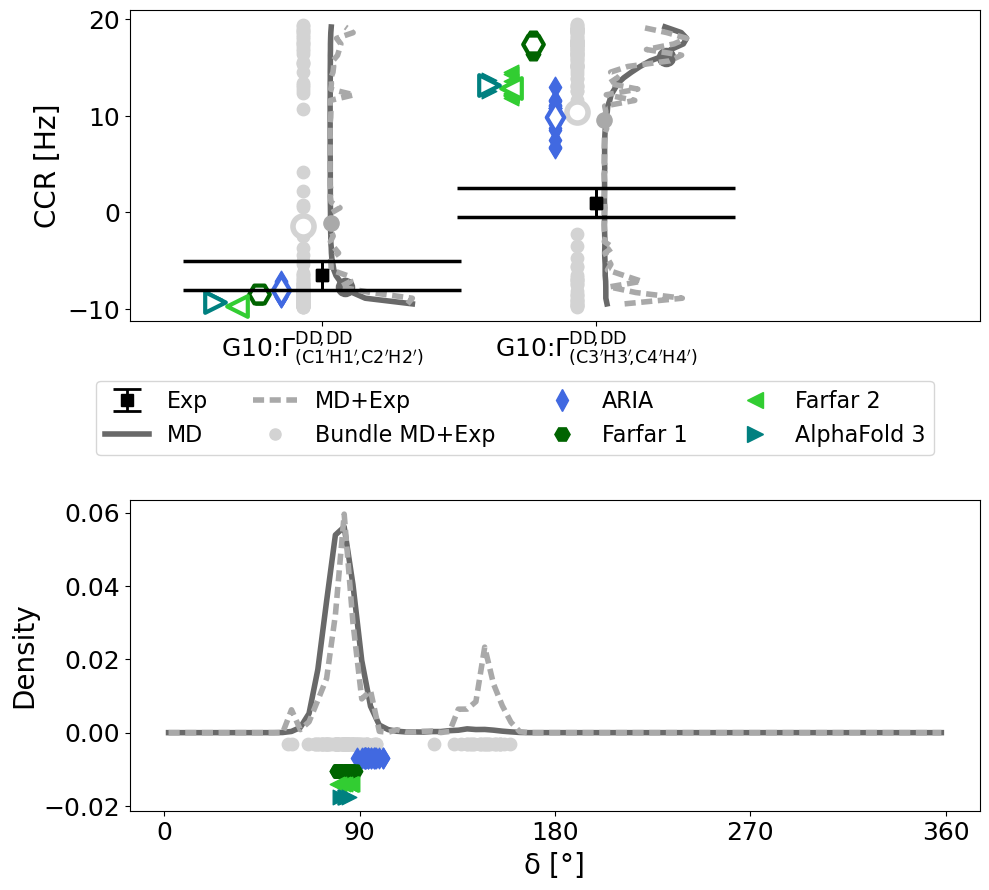

In [43]:
for i,r in enumerate(loop_res):
    plot_angle_measurement_si(r, 'delta', ['H1H2', 'H2H3', 'H3H4'], 'j3', save=True)
    plot_angle_measurement_si(r, 'delta', ['C1-C2', 'C3-C4'], 'hcch', save=True)

## $\epsilon$

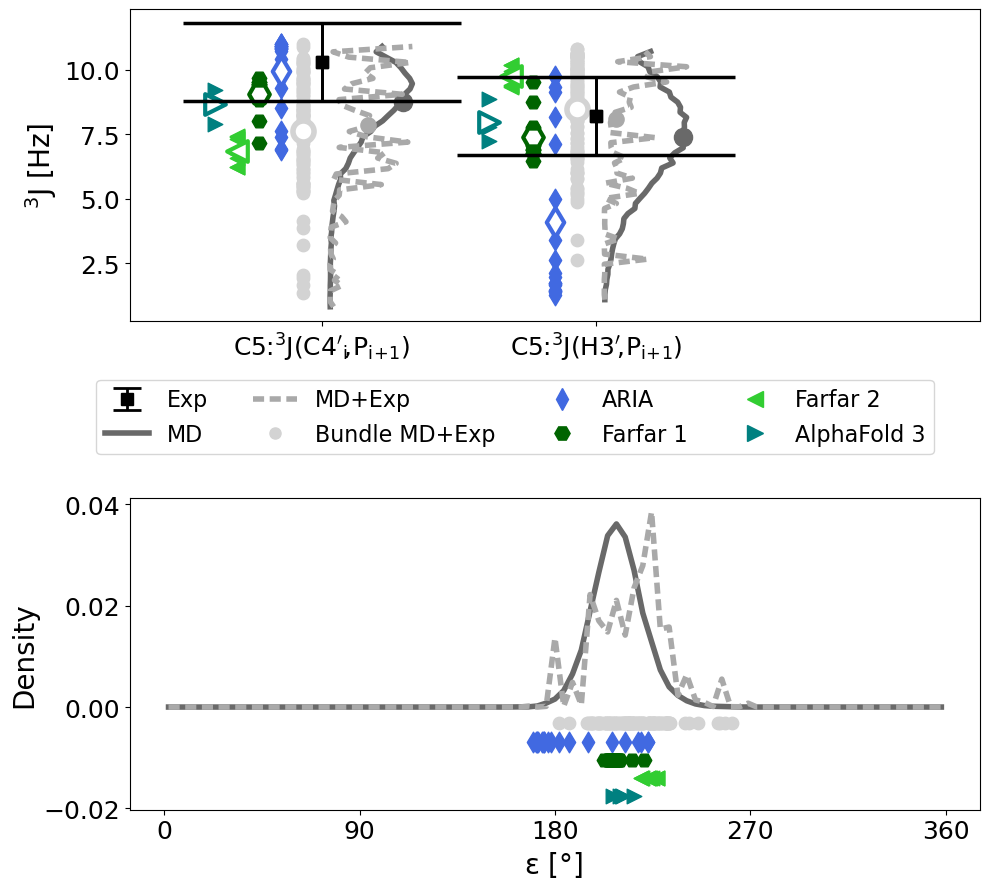

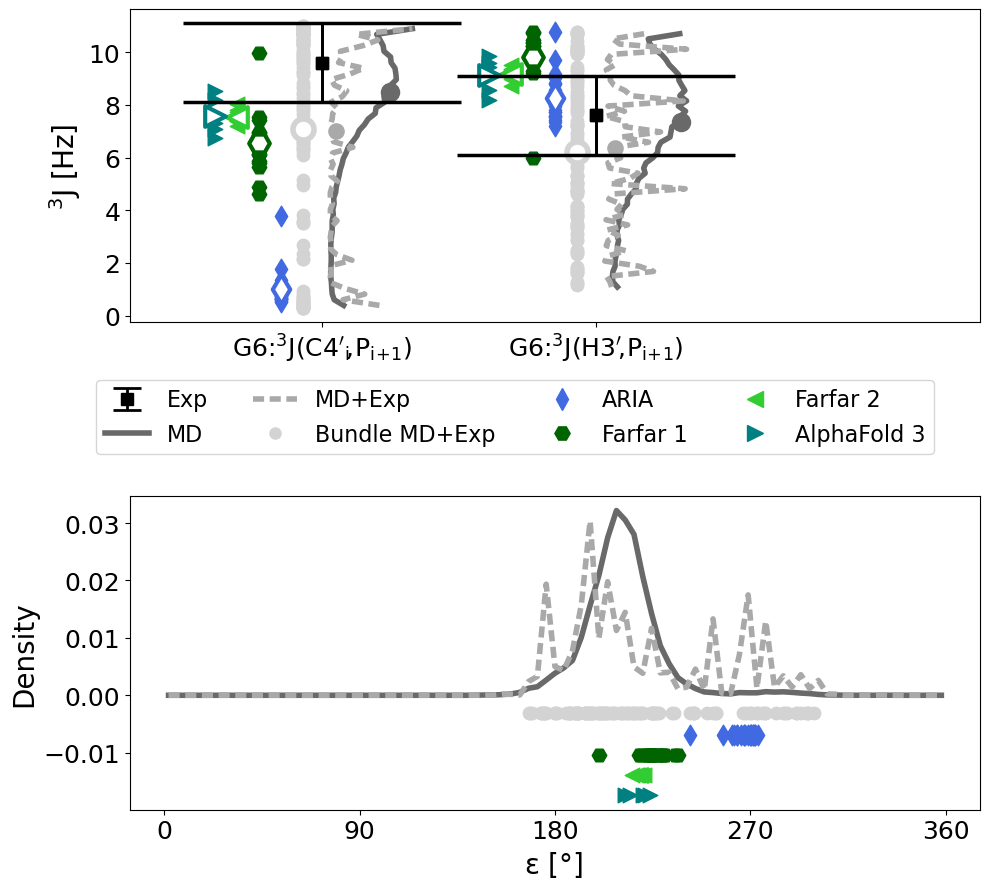

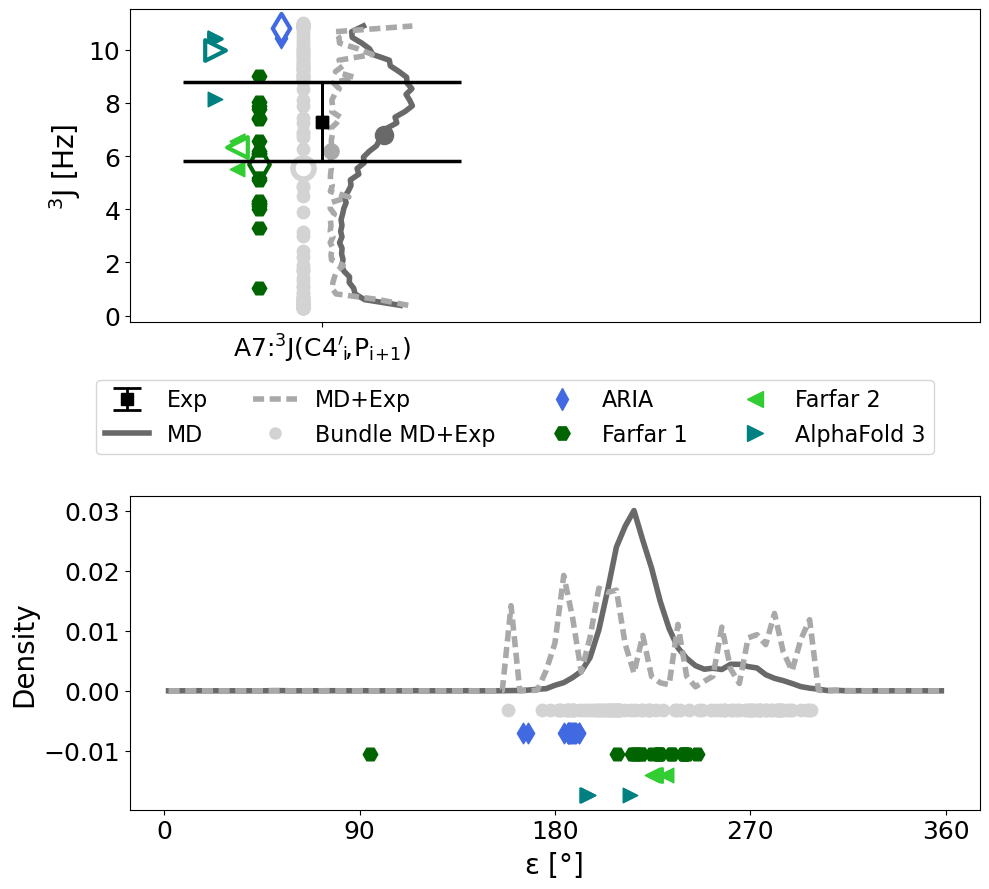

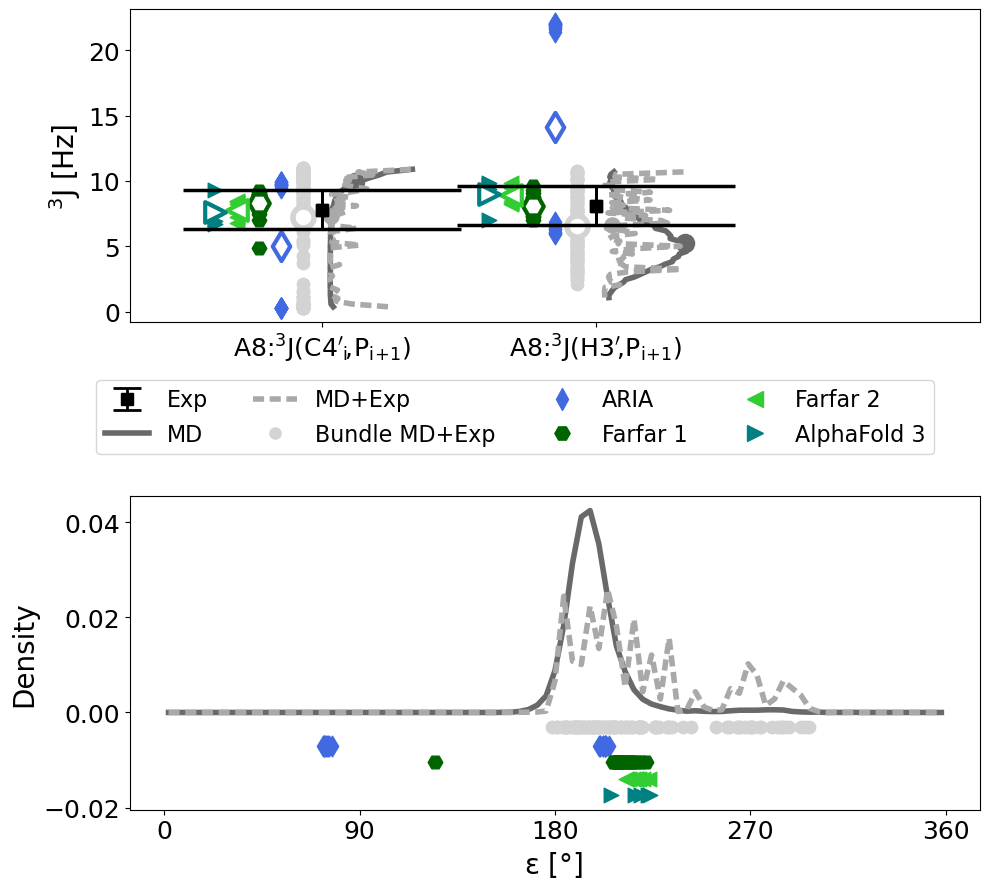

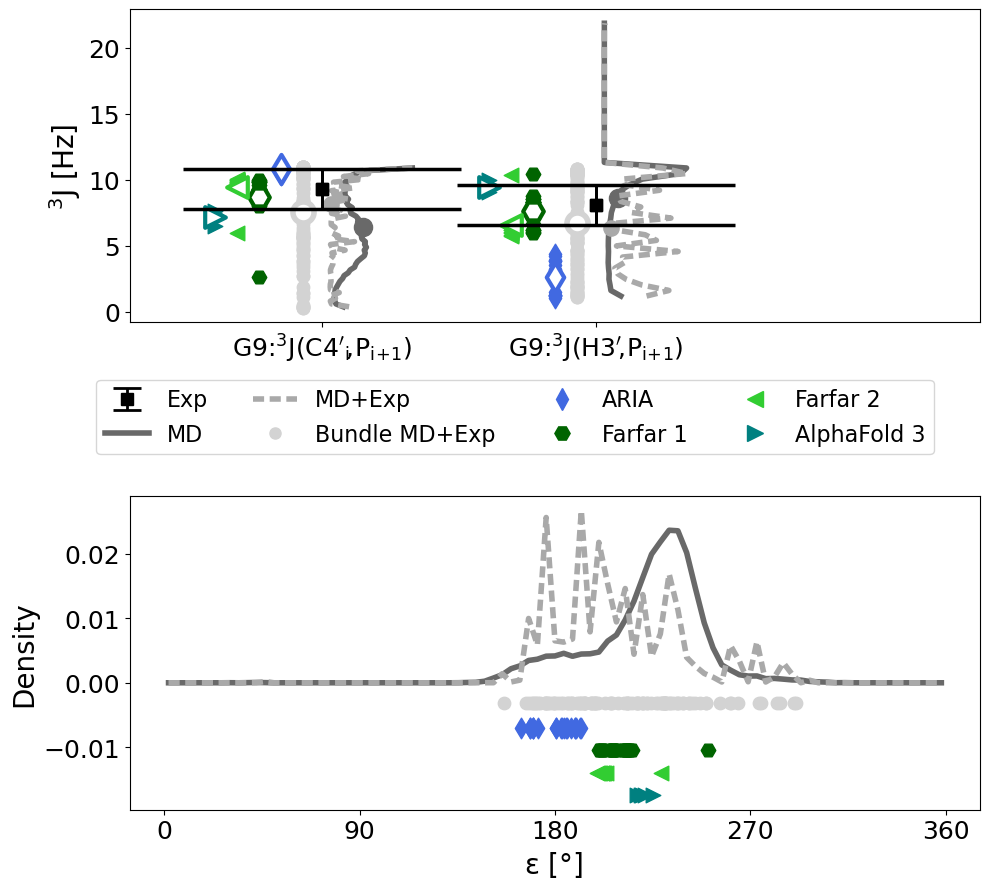

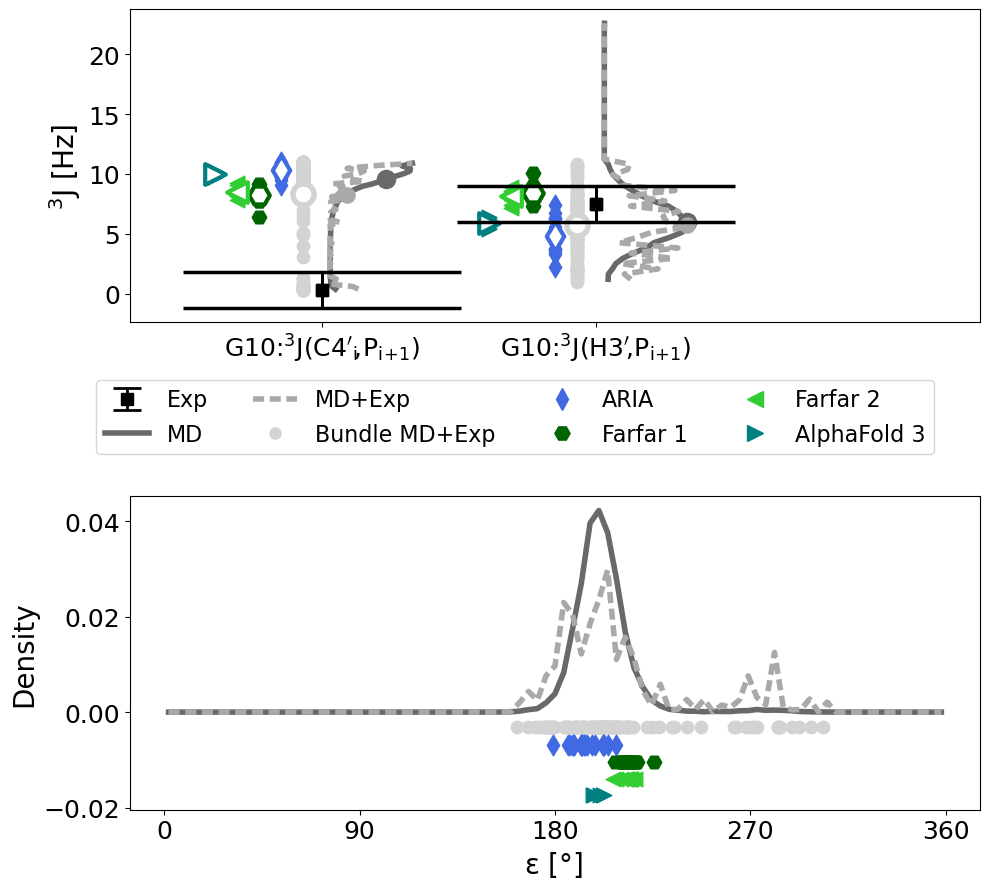

In [36]:
for i,r in enumerate(loop_res):
    plot_angle_measurement_si(r, 'eps', ['C4Pe', 'H3P'], 'j3', save=True)

## $\zeta$

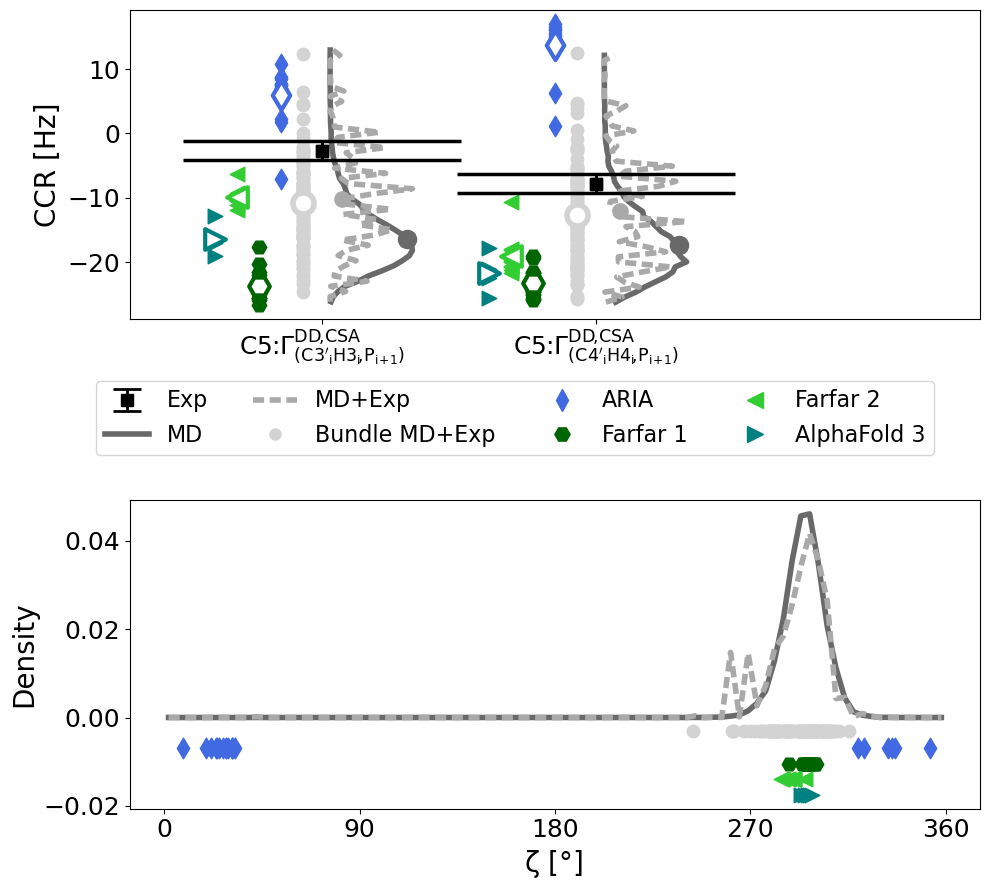

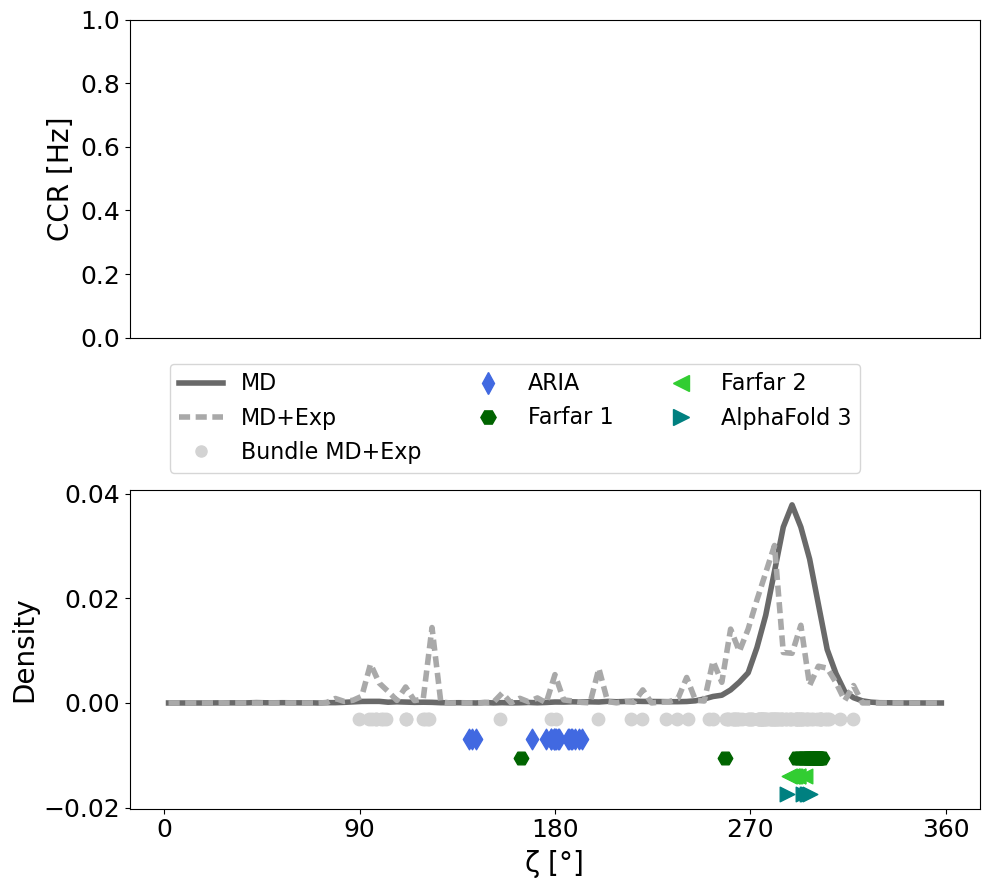

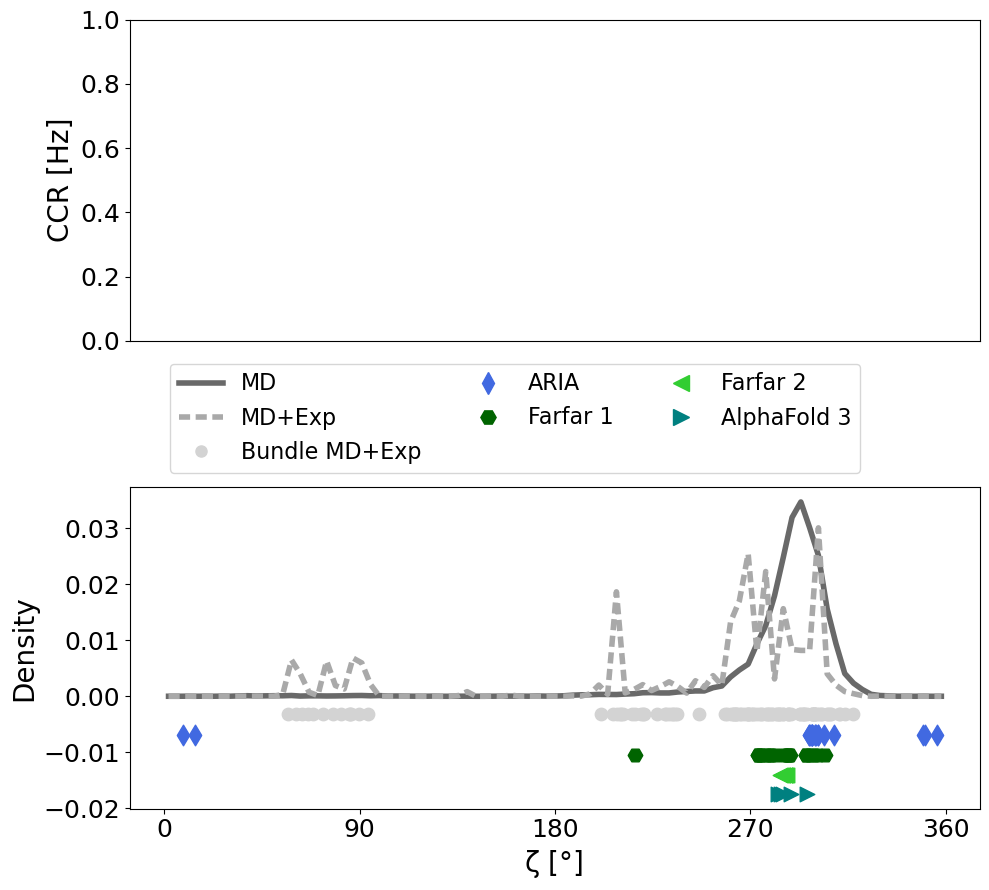

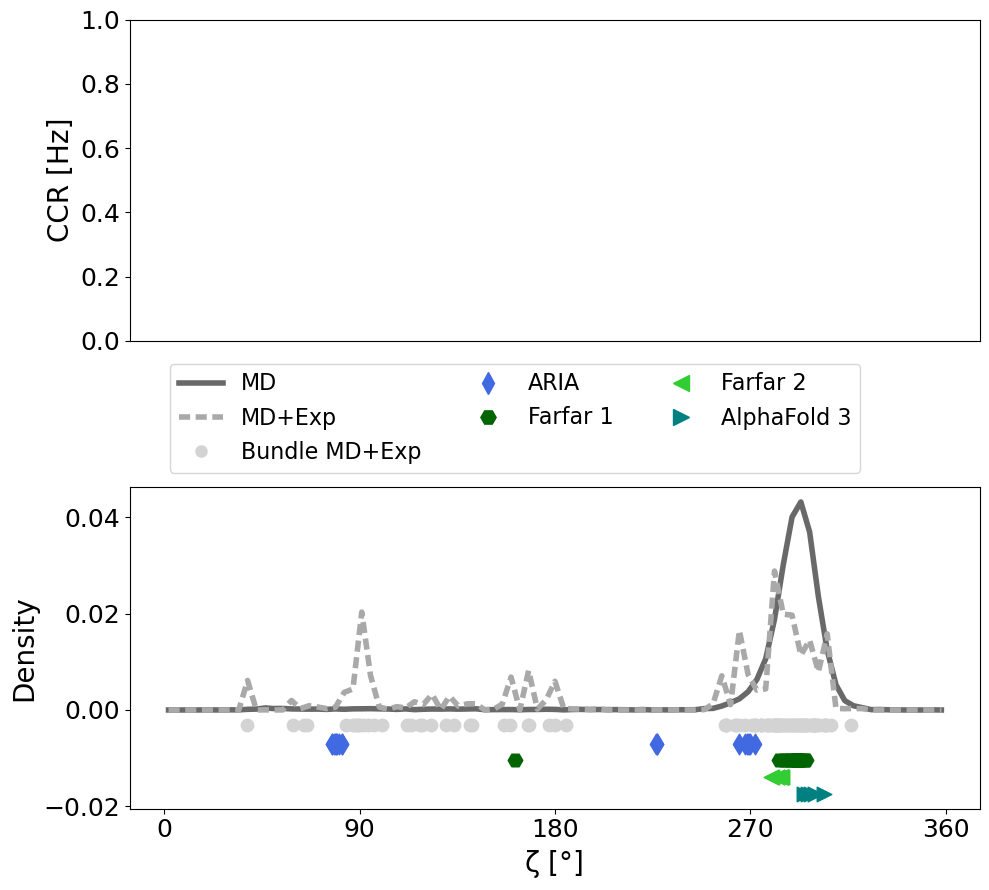

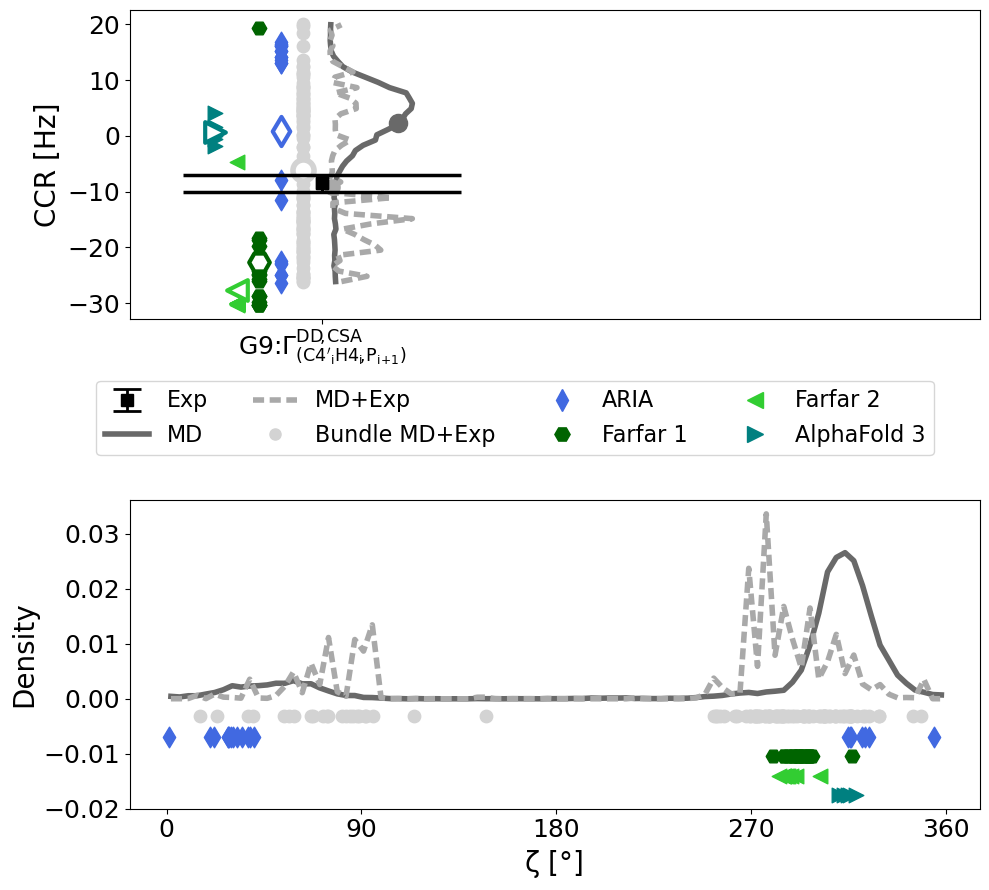

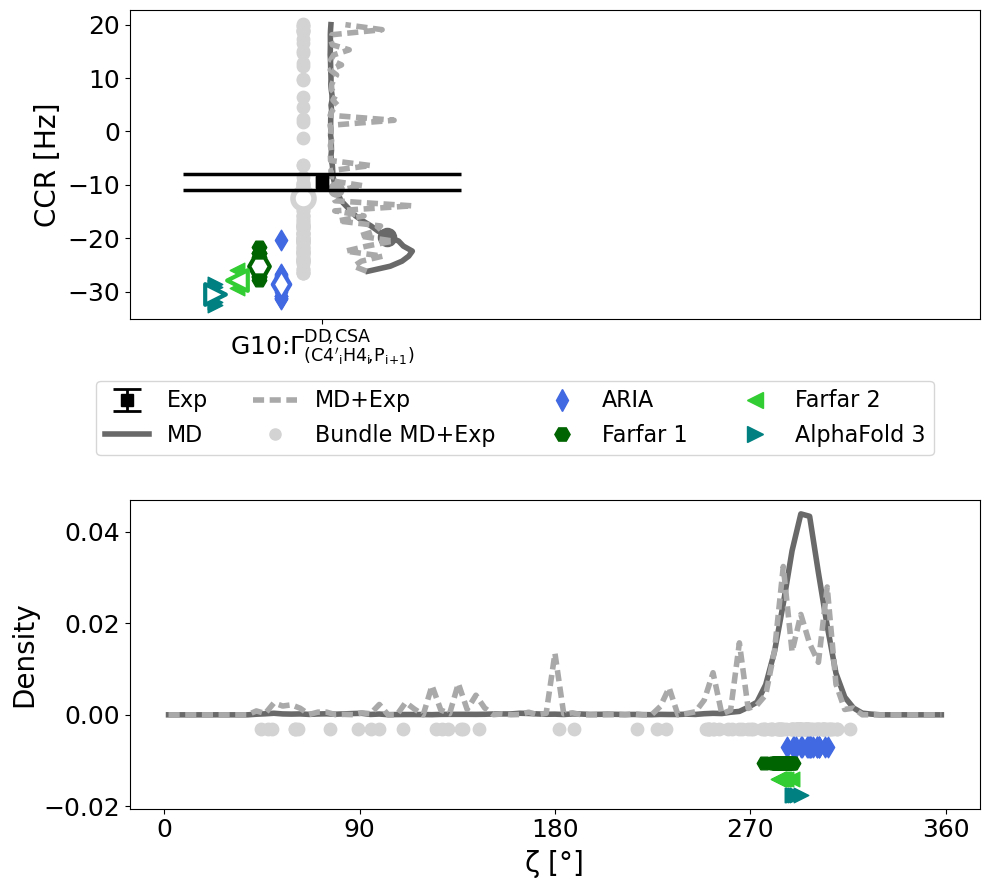

In [37]:
for i,r in enumerate(loop_res):
    plot_angle_measurement_si(r, 'zeta', ['C3p-P-plus', 'C4p-P-plus'], 'hcp', save=True)